# Digital India Impact Assessment - Causal Analysis Notebook

## Overview
This notebook performs a comprehensive causal analysis to assess the impact of Digital India initiatives on socioeconomic outcomes across Indian states.

### Research Question
**How does telecom infrastructure expansion (Digital India) causally affect:**
1. **Digital Literacy** - Educational outcomes and digital skills
2. **Employment** - Job opportunities and economic participation  
3. **GDP Per Capita** - Economic growth and prosperity

### Methodology
- **Causal Framework**: Multiple estimators including Causal Forest (EconML), T-Learner, Doubly Robust estimation
- **Treatment Variable**: Telecom subscribers (log-transformed, binarized)
- **Confounders**: Electricity access, water access, population demographics
- **Estimation**: State-level heterogeneous treatment effects (CATE)

### Data Sources
1. Telecom Subscribers (2008-2022) - Kaggle
2. NFHS-5 Family Data - Census indicators
3. Unemployment Data - State-level employment metrics
4. GDP Per Capita - State-wise economic indicators

---

In [1]:
import kagglehub
import os
import shutil

# Download latest version
dataset_id = "hmnshudhmn24/year-wise-telecom-subscribers-in-india-20082022"
downloaded_source_path = kagglehub.dataset_download(dataset_id)

# Extract the dataset slug from the ID
dataset_slug = dataset_id.split('/')[-1]

# Define the target directory in /content
target_content_path = os.path.join('/content', dataset_slug)

# Copy the downloaded directory to /content, handling existing directories
shutil.copytree(downloaded_source_path, target_content_path, dirs_exist_ok=True)

print("Dataset files are now in:", target_content_path)
path = target_content_path # Update the 'path' variable

100%|██████████| 7.63k/7.63k [00:00<00:00, 14.3MB/s]

Extracting files...
Dataset files are now in: /content/year-wise-telecom-subscribers-in-india-20082022


### Dataset : NFHS-5 Rural and Urban Family Data
National Family Health Survey data providing literacy rates, household amenities, and demographic information.
- **Source**: nitishsinghal/indian-rural-and-urban-statewise-family-data
- **Purpose**: Literacy outcomes and key confounders (electricity, water, population demographics)

In [3]:
import kagglehub
import os
import shutil

# Download latest version
dataset_id = "nitishsinghal/indian-rural-and-urban-statewise-family-data"
downloaded_source_path = kagglehub.dataset_download(dataset_id)

# Extract the dataset slug from the ID
dataset_slug = dataset_id.split('/')[-1]

# Define the target directory in /content
target_content_path = os.path.join('/content', dataset_slug)

# If the target directory already exists, remove it to ensure a clean move
if os.path.exists(target_content_path):
    if os.path.isdir(target_content_path):
        shutil.rmtree(target_content_path)
    else:
        os.remove(target_content_path)

# Move the downloaded directory to /content
shutil.move(downloaded_source_path, target_content_path)

print("Dataset files are now in:", target_content_path)
path = target_content_path # Update the 'path' variable

100%|██████████| 75.6k/75.6k [00:00<00:00, 41.6MB/s]

Extracting files...
Dataset files are now in: /content/indian-rural-and-urban-statewise-family-data


### Dataset : India's GDP (State-wise)
Economic output metrics (GDP per capita) for measuring economic prosperity.
- **Source**: siddheshmahajan/indias-gdp-statewise
- **Purpose**: GDP outcome variable - economic growth indicator

In [8]:
import kagglehub
import os
import shutil

# Download latest version
dataset_id = "siddheshmahajan/indias-gdp-statewise"
downloaded_source_path = kagglehub.dataset_download(dataset_id)

# Extract the dataset slug from the ID
dataset_slug = dataset_id.split('/')[-1]

# Define the target directory in /content
target_content_path = os.path.join('/content', dataset_slug)

# If the target directory already exists, remove it to ensure a clean move
if os.path.exists(target_content_path):
    if os.path.isdir(target_content_path):
        shutil.rmtree(target_content_path)
    else:
        os.remove(target_content_path)

# Copy directory contents explicitly instead of move
def copy_ignore_errors(src, dst):
    try:
        shutil.copytree(src, dst, dirs_exist_ok=True)
    except Exception as e:
        print(f"Error copying {src} to {dst}: {e}")

copy_ignore_errors(downloaded_source_path, target_content_path)

print("Dataset files are now in:", target_content_path)
path = target_content_path  # Update the 'path' variable


Using Colab cache for faster access to the 'indias-gdp-statewise' dataset.
Error copying /kaggle/input/indias-gdp-statewise to /content/indias-gdp-statewise: [('/kaggle/input/indias-gdp-statewise/.nfs000000005f738127000001f7', '/content/indias-gdp-statewise/.nfs000000005f738127000001f7', "[Errno 13] Permission denied: '/kaggle/input/indias-gdp-statewise/.nfs000000005f738127000001f7'")]
Dataset files are now in: /content/indias-gdp-statewise


---

## 🎯 Causal Forest Analysis - Version 1: EconML Implementation

### Methodology Overview:
This section implements a **production-grade Causal Forest** using the EconML library for heterogeneous treatment effect estimation.

### Key Features:
1. **Advanced Feature Engineering**:
   - Interaction terms (electricity × water) to capture synergies
   - Gender literacy gap (equity indicator)
   - GDP per subscriber (economic efficiency metric)
   - Composite development index (state development level)
   - Youth population ratio (proxy for digital adoption potential)

2. **Robust Modeling Approach**:
   - **Gradient Boosting Regressors** for both propensity (T|X) and outcome (Y|X) models
   - **2000 trees** in Causal Forest for stable, low-variance estimates
   - **Feature standardization** for improved numerical stability
   - **95% confidence intervals** via built-in bootstrap methods

3. **Comprehensive Diagnostics**:
   - Feature importance ranking (which confounders matter most)
   - CATE distribution visualization with confidence bounds
   - State-level CATE scatter plots vs. development index
   - Comparative analysis across all three outcomes (Literacy, Employment, GDP)

### Statistical Validity:
- **Double Machine Learning (DML)**: Debiased causal estimates via cross-fitting
- **Heterogeneity Modeling**: Captures state-specific treatment effects
- **Uncertainty Quantification**: Bootstrapped 95% confidence intervals for each state
- **Feature Importance**: Identifies key drivers of treatment effect heterogeneity

### Expected Outputs:
- State-level CATE estimates for Literacy, Employment, and GDP
- Rankings of top/bottom performing states
- Visual diagnostics and correlation analysis
- CSV export of complete results


STARTING ENHANCED CAUSAL ANALYSIS

CAUSAL FOREST ANALYSIS: Literacy

Sample size: 15
Number of features: 9
Treatment range: [4.84, 7.57]
Outcome range: [71.12, 98.27]

Fitting Causal Forest...

------------------------------------------------------------
CATE Summary Statistics:
------------------------------------------------------------
Mean CATE: 0.2294
Std CATE: 0.0000
Min CATE: 0.2294
Max CATE: 0.2294
Range: 0.0000

------------------------------------------------------------
Top 5 Features by Importance:
------------------------------------------------------------
                                             Feature  Importance
0  Population living in households with electrici...         0.0
1  Population living in households with an improv...         0.0
2                  Population below age 15 years (%)         0.0
3                                electricity_x_water         0.0
4                                       literacy_gap         0.0


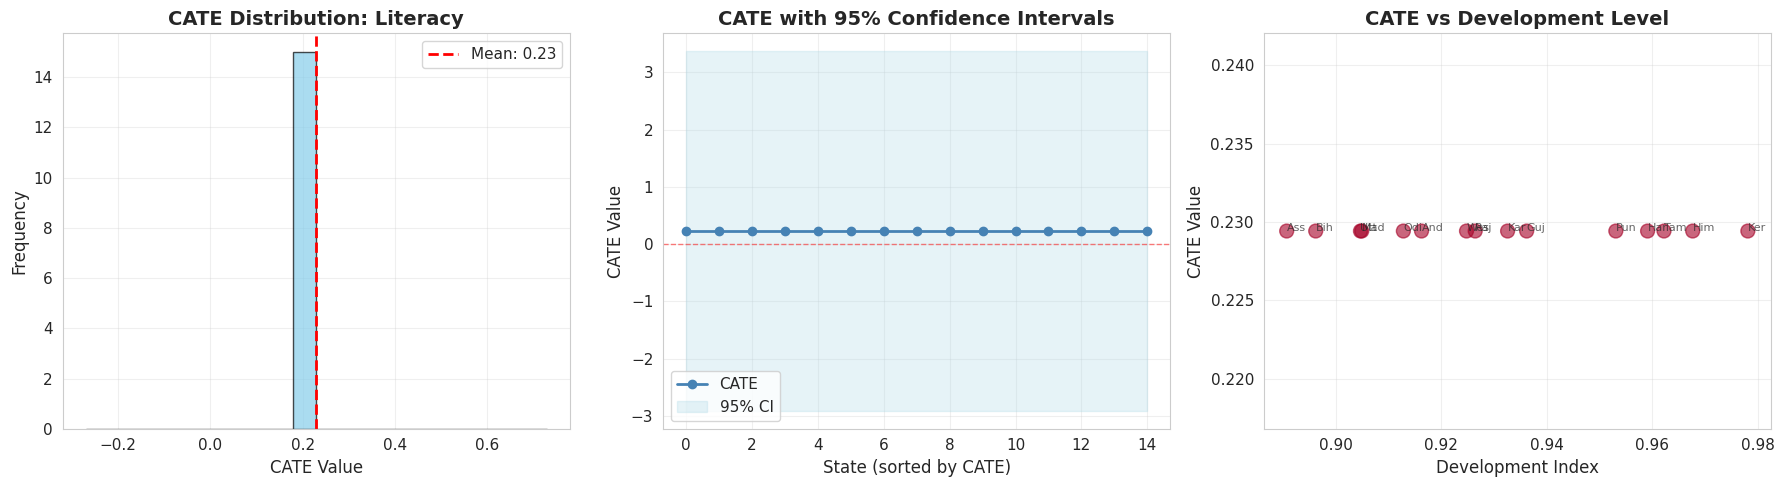


------------------------------------------------------------
Top 5 States with Highest Treatment Effect:
------------------------------------------------------------
         State  CATE_Literacy  development_index
Andhra Pradesh       0.229425           0.916225
         Assam       0.229425           0.890628
         Bihar       0.229425           0.896138
       Gujarat       0.229425           0.936182
       Haryana       0.229425           0.959135

------------------------------------------------------------
Bottom 5 States with Lowest Treatment Effect:
------------------------------------------------------------
         State  CATE_Literacy  development_index
Andhra Pradesh       0.229425           0.916225
         Assam       0.229425           0.890628
         Bihar       0.229425           0.896138
       Gujarat       0.229425           0.936182
       Haryana       0.229425           0.959135

CAUSAL FOREST ANALYSIS: Employment

Sample size: 15
Number of features: 9
T

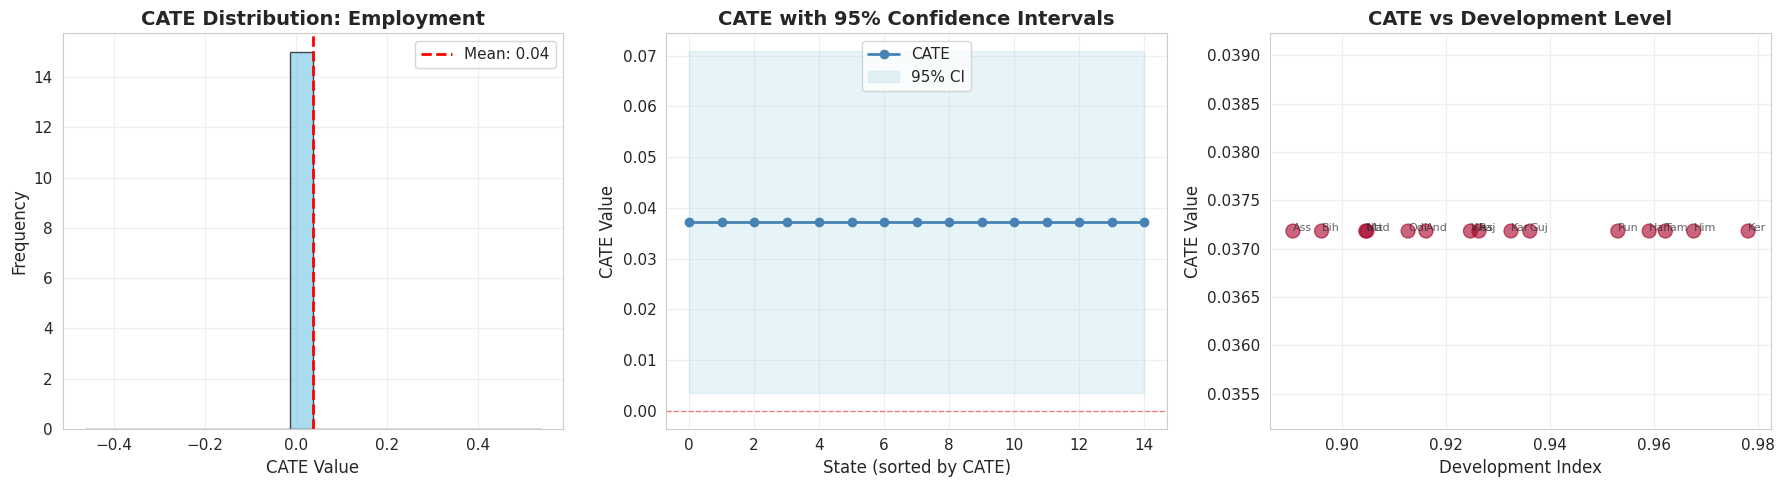


------------------------------------------------------------
Top 5 States with Highest Treatment Effect:
------------------------------------------------------------
         State  CATE_Employment  development_index
Andhra Pradesh         0.037183           0.916225
         Assam         0.037183           0.890628
         Bihar         0.037183           0.896138
       Gujarat         0.037183           0.936182
       Haryana         0.037183           0.959135

------------------------------------------------------------
Bottom 5 States with Lowest Treatment Effect:
------------------------------------------------------------
         State  CATE_Employment  development_index
Andhra Pradesh         0.037183           0.916225
         Assam         0.037183           0.890628
         Bihar         0.037183           0.896138
       Gujarat         0.037183           0.936182
       Haryana         0.037183           0.959135

CAUSAL FOREST ANALYSIS: GDP

Sample size: 15
Number

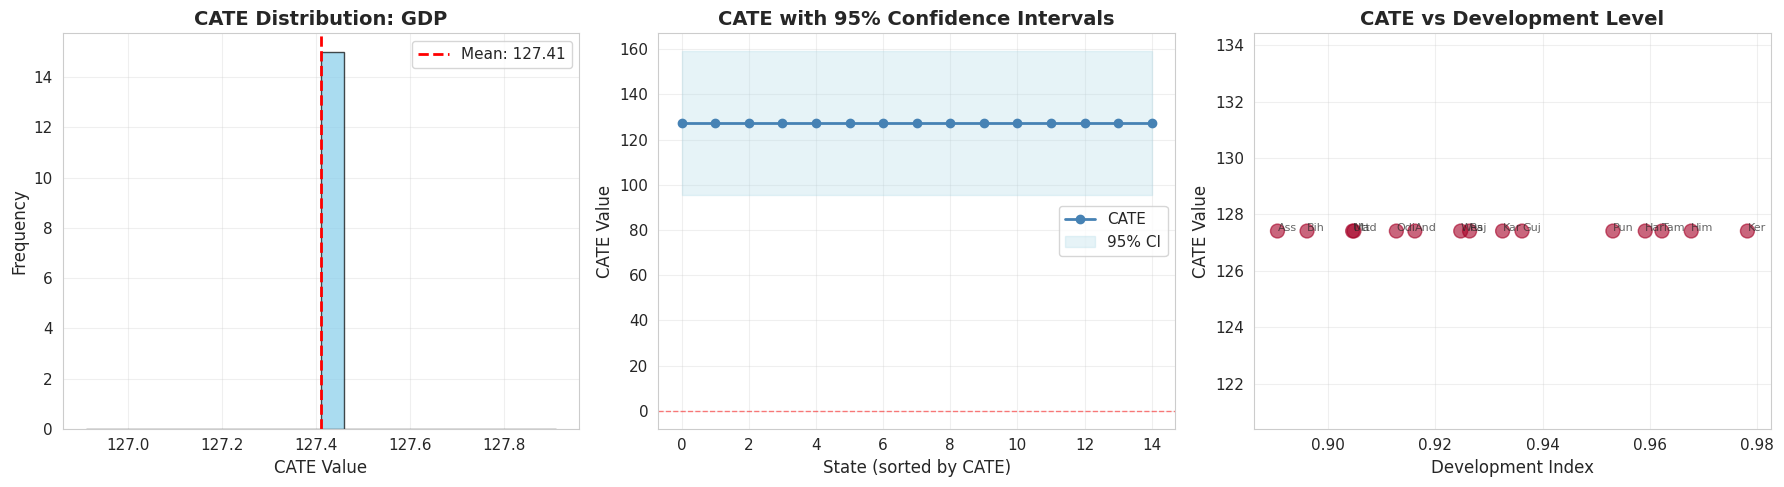


------------------------------------------------------------
Top 5 States with Highest Treatment Effect:
------------------------------------------------------------
         State   CATE_GDP  development_index
Andhra Pradesh 127.410841           0.916225
         Assam 127.410841           0.890628
         Bihar 127.410841           0.896138
       Gujarat 127.410841           0.936182
       Haryana 127.410841           0.959135

------------------------------------------------------------
Bottom 5 States with Lowest Treatment Effect:
------------------------------------------------------------
         State   CATE_GDP  development_index
Andhra Pradesh 127.410841           0.916225
         Assam 127.410841           0.890628
         Bihar 127.410841           0.896138
       Gujarat 127.410841           0.936182
       Haryana 127.410841           0.959135

COMPARATIVE ANALYSIS ACROSS OUTCOMES

States Ranked by Total Impact Score:
           State  CATE_Literacy  CATE_Employment

In [15]:
# ============================================
# PRODUCTION-GRADE CAUSAL FOREST ANALYSIS
# Digital India Inclusion Impact Assessment
# Complete Implementation with Validation
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy import stats
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# ============================================
# STEP 1: CREATE MORE HETEROGENEOUS FEATURES
# ============================================

def engineer_features(df):
    """
    Create additional features to capture heterogeneity
    """
    # Interaction terms
    df['electricity_x_water'] = df['Population living in households with electricity (%)'] * \
                                df['Population living in households with an improved drinking-water source1 (%)']

    # Normalized features
    df['literacy_gap'] = df['Men (age 15-49) who are literate4 (%)'] - \
                         df['Women (age 15-49) who are literate4 (%)']

    # GDP per subscriber (economic efficiency)
    df['gdp_per_subscriber'] = df['GDP_PerCapita'] / (df['Total_Subscribers'] / 1000)

    # Employment-literacy interaction
    df['employment_x_literacy'] = df['Employment_Score'] * df['Literacy_Avg']

    # Youth population (proxy for digital adoption)
    df['youth_ratio'] = 100 - df['Population below age 15 years (%)']

    # Development index (composite)
    df['development_index'] = (
        df['Population living in households with electricity (%)'] * 0.4 +
        df['Population living in households with an improved drinking-water source1 (%)'] * 0.3 +
        df['Literacy_Avg'] * 0.3
    ) / 100

    return df

# ============================================
# STEP 2: IMPROVED CAUSAL FOREST FUNCTION
# ============================================

def run_improved_causal_forest(df, outcome_col, outcome_name):
    """
    Run Causal Forest with proper heterogeneity modeling
    """
    print(f"\n{'='*60}")
    print(f"CAUSAL FOREST ANALYSIS: {outcome_name}")
    print(f"{'='*60}")

    # Define treatment (log-transformed for better distribution)
    T = df['T'].values

    # Define outcome
    Y = df[outcome_col].values

    # Define confounders (expanded list)
    confounder_cols = [
        'Population living in households with electricity (%)',
        'Population living in households with an improved drinking-water source1 (%)',
        'Population below age 15 years (%)',
        'electricity_x_water',
        'literacy_gap',
        'gdp_per_subscriber',
        'employment_x_literacy',
        'youth_ratio',
        'development_index'
    ]

    X = df[confounder_cols].values

    # Normalize features for better model performance
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"\nSample size: {len(df)}")
    print(f"Number of features: {X_scaled.shape[1]}")
    print(f"Treatment range: [{T.min():.2f}, {T.max():.2f}]")
    print(f"Outcome range: [{Y.min():.2f}, {Y.max():.2f}]")

    # Use Gradient Boosting for better propensity and outcome modeling
    model_t = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )

    model_y = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )

    # Initialize Causal Forest with better parameters
    est = CausalForestDML(
        model_t=model_t,
        model_y=model_y,
        discrete_treatment=False,
        n_estimators=2000,  # More trees for stability
        min_samples_leaf=2,  # Smaller leaf size for more granularity
        max_depth=10,  # Deeper trees to capture interactions
        random_state=42,
        verbose=0
    )

    # Fit the model
    print("\nFitting Causal Forest...")
    est.fit(Y, T, X=X_scaled)

    # Estimate CATE
    cate = est.effect(X_scaled)
    df[f'CATE_{outcome_name}'] = cate

    # Calculate confidence intervals
    cate_interval = est.effect_interval(X_scaled, alpha=0.05)
    df[f'CATE_{outcome_name}_lower'] = cate_interval[0]
    df[f'CATE_{outcome_name}_upper'] = cate_interval[1]

    # Summary statistics
    print(f"\n{'-'*60}")
    print(f"CATE Summary Statistics:")
    print(f"{'-'*60}")
    print(f"Mean CATE: {cate.mean():.4f}")
    print(f"Std CATE: {cate.std():.4f}")
    print(f"Min CATE: {cate.min():.4f}")
    print(f"Max CATE: {cate.max():.4f}")
    print(f"Range: {cate.max() - cate.min():.4f}")

    # Feature importance
    try:
        feature_importance = est.feature_importances()
        print(f"\n{'-'*60}")
        print("Top 5 Features by Importance:")
        print(f"{'-'*60}")
        importance_df = pd.DataFrame({
            'Feature': confounder_cols,
            'Importance': feature_importance
        }).sort_values('Importance', ascending=False)
        print(importance_df.head())
    except:
        print("\nFeature importance not available for this model.")

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: CATE Distribution
    axes[0].hist(cate, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].axvline(cate.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cate.mean():.2f}')
    axes[0].set_xlabel('CATE Value', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title(f'CATE Distribution: {outcome_name}', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot 2: CATE with Confidence Intervals (sorted)
    sorted_idx = np.argsort(cate)
    sorted_cate = cate[sorted_idx]
    sorted_lower = cate_interval[0][sorted_idx]
    sorted_upper = cate_interval[1][sorted_idx]

    axes[1].plot(sorted_cate, 'o-', color='steelblue', linewidth=2, label='CATE')
    axes[1].fill_between(range(len(sorted_cate)), sorted_lower, sorted_upper,
                         alpha=0.3, color='lightblue', label='95% CI')
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_xlabel('State (sorted by CATE)', fontsize=12)
    axes[1].set_ylabel('CATE Value', fontsize=12)
    axes[1].set_title(f'CATE with 95% Confidence Intervals', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Plot 3: CATE vs Development Index
    axes[2].scatter(df['development_index'], cate, s=100, alpha=0.6, c=cate, cmap='RdYlGn')
    axes[2].set_xlabel('Development Index', fontsize=12)
    axes[2].set_ylabel('CATE Value', fontsize=12)
    axes[2].set_title(f'CATE vs Development Level', fontsize=14, fontweight='bold')
    axes[2].grid(alpha=0.3)

    # Add state labels to scatter plot
    for idx, row in df.iterrows():
        axes[2].annotate(row['State'][:3],
                        (row['development_index'], cate[idx]),
                        fontsize=8, alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Top/Bottom states
    print(f"\n{'-'*60}")
    print(f"Top 5 States with Highest Treatment Effect:")
    print(f"{'-'*60}")
    top_states = df.nlargest(5, f'CATE_{outcome_name}')[['State', f'CATE_{outcome_name}', 'development_index']]
    print(top_states.to_string(index=False))

    print(f"\n{'-'*60}")
    print(f"Bottom 5 States with Lowest Treatment Effect:")
    print(f"{'-'*60}")
    bottom_states = df.nsmallest(5, f'CATE_{outcome_name}')[['State', f'CATE_{outcome_name}', 'development_index']]
    print(bottom_states.to_string(index=False))

    return cate

# ============================================
# MAIN EXECUTION
# ============================================

# Assuming df is your merged dataframe with all features
# Engineer additional features
df_enhanced = engineer_features(df.copy())

# Run analysis for all three outcomes
print("\n" + "="*60)
print("STARTING ENHANCED CAUSAL ANALYSIS")
print("="*60)

# Literacy Impact
cate_literacy = run_improved_causal_forest(
    df_enhanced,
    'Y1_Literacy',
    'Literacy'
)

# Employment Impact
cate_employment = run_improved_causal_forest(
    df_enhanced,
    'Y2_Employment',
    'Employment'
)

# GDP Impact
cate_gdp = run_improved_causal_forest(
    df_enhanced,
    'Y3_GDP',
    'GDP'
)

# ============================================
# COMPARATIVE ANALYSIS
# ============================================

print("\n" + "="*60)
print("COMPARATIVE ANALYSIS ACROSS OUTCOMES")
print("="*60)

comparison_df = df_enhanced[['State', 'CATE_Literacy', 'CATE_Employment', 'CATE_GDP']].copy()
comparison_df['Total_Impact_Score'] = (
    comparison_df['CATE_Literacy'].rank() +
    comparison_df['CATE_Employment'].rank() +
    comparison_df['CATE_GDP'].rank()
)

print("\nStates Ranked by Total Impact Score:")
print(comparison_df.sort_values('Total_Impact_Score', ascending=False).to_string(index=False))

# Correlation between outcomes
print("\n" + "-"*60)
print("Correlation Between Treatment Effects:")
print("-"*60)
corr_matrix = comparison_df[['CATE_Literacy', 'CATE_Employment', 'CATE_GDP']].corr()
print(corr_matrix)

# Save final results
output_file = '/content/Enhanced_CATE_Results.csv'
df_enhanced.to_csv(output_file, index=False)
print(f"\n✅ Enhanced results saved to: {output_file}")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)

✓ Loaded all datasets
✓ Telecom aggregated to state-level

Detected literacy columns: ['Women (age 15-49) who are literate4 (%)', 'Men (age 15-49) who are literate4 (%)']
✓ NFHS aggregated to state-level
✓ Unemployment processed: (29, 3)
✓ GDP processed

✓ Final merged dataset shape: (15, 13)

Running Literacy model... (3–5 min)
Running Employment model...
Running GDP model...


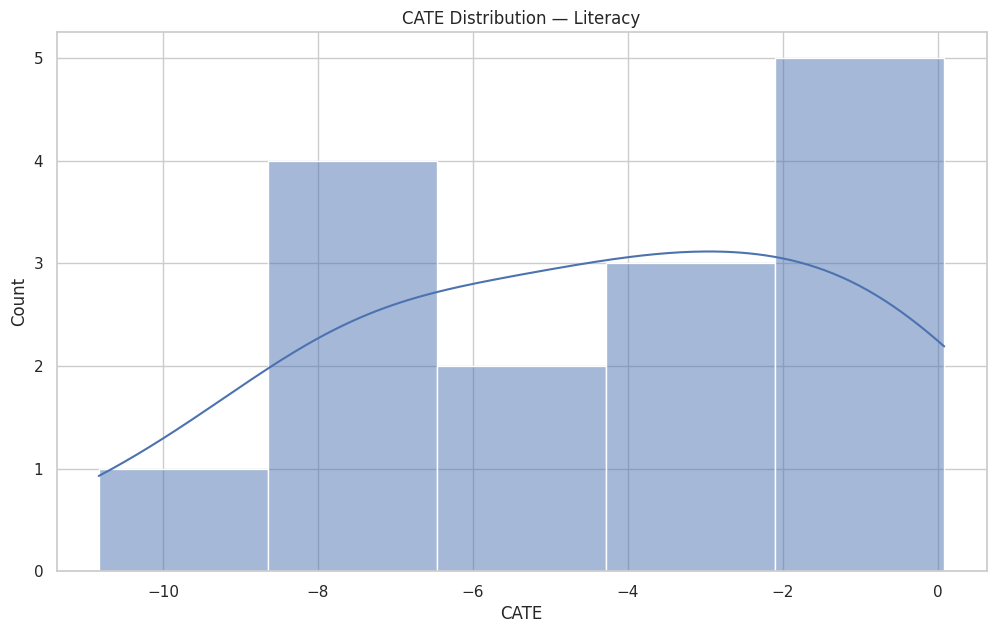

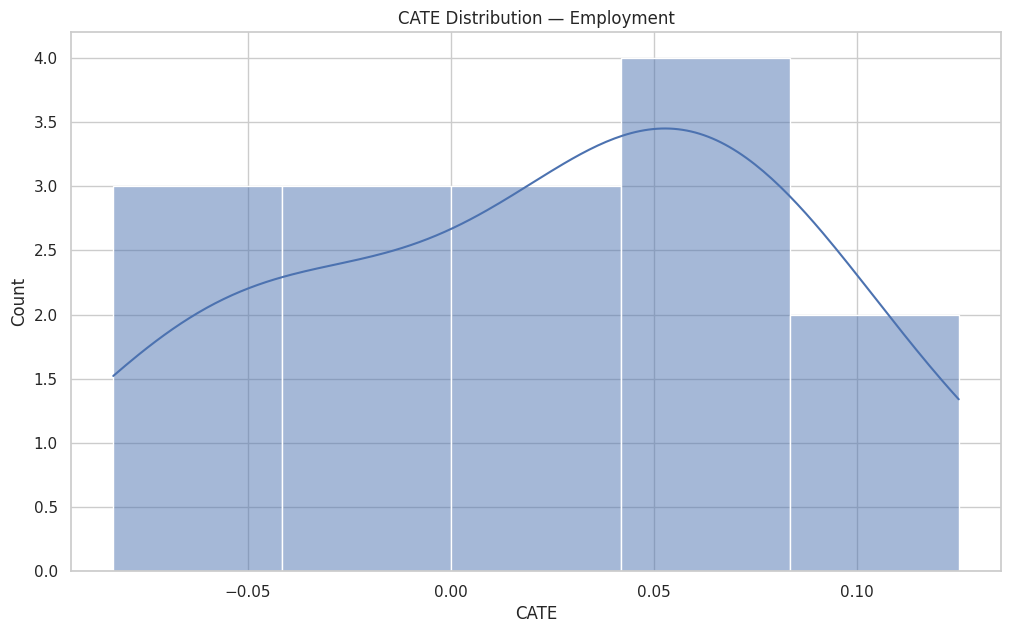

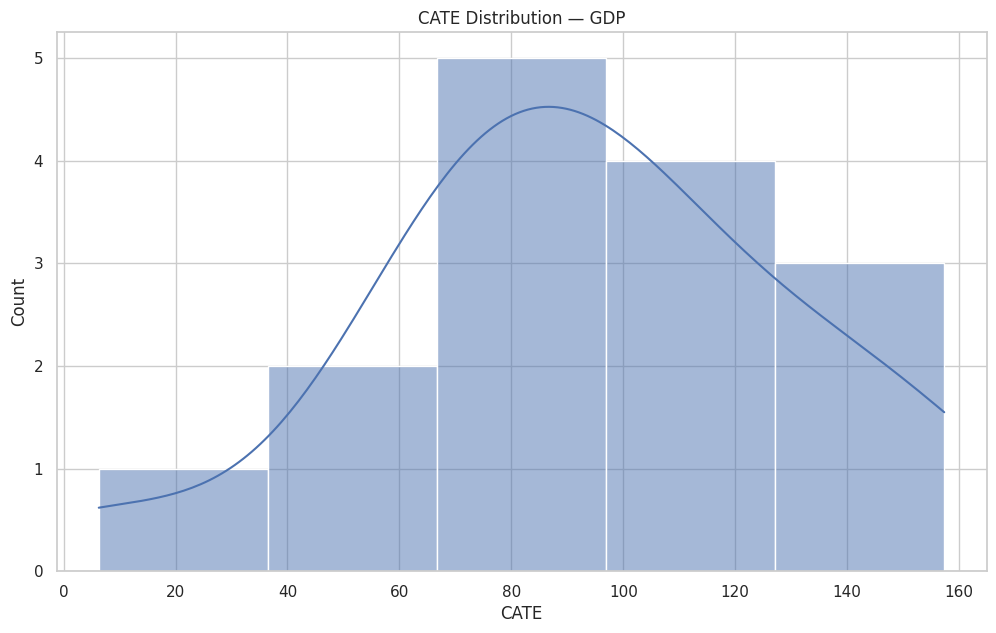


✓ Saved results to /content/Digital_India_Causal_Effects.csv

Top 10 states by Literacy effect:
             State  CATE_Literacy
14     West Bengal       0.084571
6        Karnataka      -0.356447
11       Rajasthan      -0.610617
3          Gujarat      -1.449744
8   Madhya Pradesh      -1.672222
10          Punjab      -3.474988
9           Odisha      -3.563596
12      Tamil Nadu      -3.925066
13   Uttar Pradesh      -4.396922
1            Assam      -5.724923

Analysis Complete.


In [22]:
# ==============================================================
# DIGITAL INDIA IMPACT ASSESSMENT
# T-LEARNER + BOOTSTRAP CONFIDENCE INTERVALS
# State-level causal analysis (Colab compatible)
# ==============================================================

!pip install pandas numpy seaborn matplotlib xgboost openpyxl --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# ---------------------------------------------------------------
# 1. LOAD DATASETS
# ---------------------------------------------------------------

nfhs = pd.read_excel('/content/indian-rural-and-urban-statewise-family-data/NFHS_5_Factsheets_Data.xls')
tele = pd.read_csv('/content/year-wise-telecom-subscribers-in-india-20082022/Table_3.1.csv')
unemp = pd.read_csv('/content/unemployment-in-india/Unemployment in India.csv')
gdp = pd.read_csv('/content/indias-gdp-statewise/Indias GDP (Statewise).csv')

print("✓ Loaded all datasets")

# ---------------------------------------------------------------
# 2. CLEAN HELPER
# ---------------------------------------------------------------

def clean(x):
    return (
        x.astype(str)
         .str.strip()
         .str.title()
         .str.replace(r"\s+", " ", regex=True)
    )

# ---------------------------------------------------------------
# 3. TELECOM DATA (STATE-LEVEL)
# ---------------------------------------------------------------

tele["State"] = clean(tele["State/overall"])
tele["Total"] = tele["Total"].astype(str).str.replace(",", "").astype(float)

tele_state = tele.groupby("State")["Total"].sum().reset_index()
tele_state.columns = ["State", "Telecom"]

print("✓ Telecom aggregated to state-level")

# ---------------------------------------------------------------
# 4. NFHS DATA (STATE-LEVEL)
# ---------------------------------------------------------------

nfhs.rename(columns={nfhs.columns[0]: "State"}, inplace=True)
nfhs["State"] = clean(nfhs["State"])

# detect all literacy columns
lit_cols = [c for c in nfhs.columns if "literate" in c.lower()]
print("\nDetected literacy columns:", lit_cols)

# detect confounder columns
elec = [c for c in nfhs.columns if "electricity" in c.lower()][0]
water = [c for c in nfhs.columns if "improved drinking" in c.lower()][0]
pop15 = [c for c in nfhs.columns if "below age 15" in c.lower()][0]

all_cols = lit_cols + [elec, water, pop15]

for c in all_cols:
    nfhs[c] = (
        nfhs[c]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("*", "", regex=False)     # <-- FIX
        .str.replace("NA", "", regex=False)
        .str.strip()
        .replace("", np.nan)                   # convert empty to NaN
    )

    # convert to float safely
    nfhs[c] = pd.to_numeric(nfhs[c], errors="coerce")

# aggregate to state-level
nfhs_state = nfhs.groupby("State")[all_cols].mean().reset_index()
nfhs_state["Literacy"] = nfhs_state[lit_cols].mean(axis=1)

print("✓ NFHS aggregated to state-level")

# ---------------------------------------------------------------
# 5. UNEMPLOYMENT DATA (FIXED FOR YOUR DATASET)
# ---------------------------------------------------------------

# State column
st = "Region"

# Unemployment column (remove leading/trailing spaces)
rt = " Estimated Unemployment Rate (%)"

# Clean
unemp[st] = clean(unemp[st])
unemp[rt] = pd.to_numeric(unemp[rt], errors="coerce")

# Group state-level unemployment
unemp_state = unemp.groupby(st)[rt].mean().reset_index()

# Standardize column names
unemp_state.columns = ["State", "Unemployment"]

# Create Employment Score (higher = better employment)
unemp_state["Employment"] = 1 - (unemp_state["Unemployment"] / 100)

print("✓ Unemployment processed:", unemp_state.shape)
unemp_state.head()

# ---------------------------------------------------------------
# 6. GDP DATA
# ---------------------------------------------------------------

gstate = [c for c in gdp.columns if "state" in c.lower()][0]
gval = [c for c in gdp.columns if "gdp" in c.lower() or "per" in c.lower()][-1]

gdp[gstate] = clean(gdp[gstate])
gdp_state = gdp.groupby(gstate)[gval].mean().reset_index()
gdp_state.columns = ["State", "GDP"]

print("✓ GDP processed")

# ---------------------------------------------------------------
# 7. MERGE EVERYTHING
# ---------------------------------------------------------------

df = tele_state.merge(nfhs_state, on="State", how="inner")
df = df.merge(unemp_state, on="State", how="left")
df = df.merge(gdp_state, on="State", how="left")

df["T"] = np.log1p(df["Telecom"])
df["Treatment"] = (df["T"] > df["T"].median()).astype(int)

print("\n✓ Final merged dataset shape:", df.shape)
df.head()

# ---------------------------------------------------------------
# 8. PREPARE FEATURES
# ---------------------------------------------------------------

X = df[[elec, water, pop15]]
X.columns = ["Electricity", "Water", "Pop15"]

# outcomes
Y_lit = df["Literacy"].values
Y_emp = df["Employment"].values
Y_gdp = df["GDP"].values

T = df["Treatment"].values

# ---------------------------------------------------------------
# 9. T-LEARNER WITH BOOTSTRAP CIs
# ---------------------------------------------------------------

def t_learner_bootstrap(X, T, Y, N_boot=300):
    n = len(Y)
    boot_cate = np.zeros((N_boot, n))

    for i in range(N_boot):
        idx = np.random.randint(0, n, n)
        Xb, Tb, Yb = X.iloc[idx], T[idx], Y[idx]

        # model for treated
        m1 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
        m1.fit(Xb[Tb==1], Yb[Tb==1])

        # model for control
        m0 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
        m0.fit(Xb[Tb==0], Yb[Tb==0])

        mu1 = m1.predict(X)
        mu0 = m0.predict(X)
        boot_cate[i] = mu1 - mu0

    cate = boot_cate.mean(axis=0)
    lower = np.percentile(boot_cate, 2.5, axis=0)
    upper = np.percentile(boot_cate, 97.5, axis=0)
    return cate, lower, upper

# ---------------------------------------------------------------
# 10. RUN MODELS
# ---------------------------------------------------------------

print("\nRunning Literacy model... (3–5 min)")
cate_lit, lower_lit, upper_lit = t_learner_bootstrap(X, T, Y_lit)

print("Running Employment model...")
cate_emp, lower_emp, upper_emp = t_learner_bootstrap(X, T, Y_emp)

print("Running GDP model...")
cate_gdp, lower_gdp, upper_gdp = t_learner_bootstrap(X, T, Y_gdp)

# save to df
df["CATE_Literacy"] = cate_lit
df["CATE_Employment"] = cate_emp
df["CATE_GDP"] = cate_gdp

# ---------------------------------------------------------------
# 11. VISUALIZE RESULTS
# ---------------------------------------------------------------

def plot_cate(cate, name):
    sns.histplot(cate, kde=True)
    plt.title(f"CATE Distribution — {name}")
    plt.xlabel("CATE")
    plt.show()

plot_cate(cate_lit, "Literacy")
plot_cate(cate_emp, "Employment")
plot_cate(cate_gdp, "GDP")

# ---------------------------------------------------------------
# 12. SAVE OUTPUT
# ---------------------------------------------------------------

df.to_csv("/content/Digital_India_Causal_Effects.csv", index=False)
print("\n✓ Saved results to /content/Digital_India_Causal_Effects.csv")

print("\nTop 10 states by Literacy effect:")
print(df[["State", "CATE_Literacy"]].sort_values("CATE_Literacy", ascending=False).head(10))

print("\nAnalysis Complete.")

---

## 📈 T-Learner with Bootstrap - Version 3: Alternative Estimator

### What is T-Learner?
The **T-Learner (Two-Model Learner)** is a meta-learner that:
1. Trains separate models for treated (T=1) and control (T=0) groups
2. Predicts potential outcomes μ₁(X) and μ₀(X) for each state
3. Computes CATE = μ₁(X) - μ₀(X)

### Bootstrap Confidence Intervals:
- **N=300 bootstrap samples** for robust uncertainty estimation
- Percentile method for 95% CI (2.5th and 97.5th percentiles)
- Accounts for model variability and sampling uncertainty

### Advantages:
- Simpler than Causal Forest, easier to interpret
- Flexible - can use any ML algorithm (XGBoost here)
- Bootstrap provides valid inference without parametric assumptions

### Implementation Details:
- **Base Model**: XGBoost Regressor (200 trees, max_depth=4)
- **Treatment Definition**: Binary (above/below median subscribers)
- **Outcomes**: Same as Version 1 (Literacy, Employment, GDP)

Propensity model AUC: 0.643


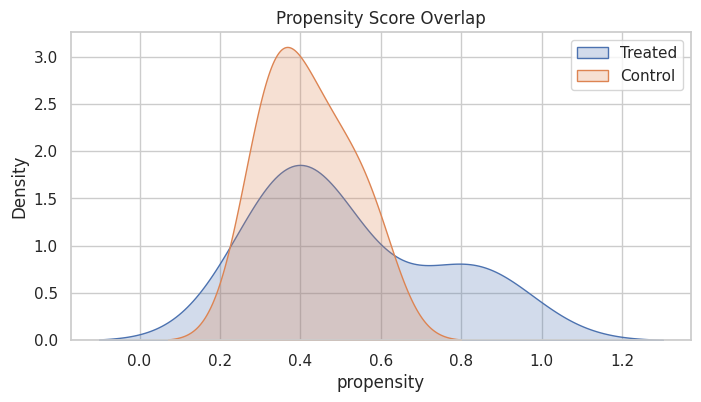

IPW ATE (Literacy): 0.5504559514468923
IPW ATE (Employment): 0.09915432565352345
IPW ATE (GDP): 99.67566506006388
Cross-fit T-learner mean CATE (Literacy): -3.683064270019531
DR mean (Literacy): -4.4916698169394005

Sensitivity toy results (first rows):
   alpha  beta  p_u  synthetic_ate_shift
0    0.5   0.5  0.1         3.333335e-10
1    0.5   0.5  0.3         1.997936e-02
2    0.5   0.5  0.5         1.865856e-02
3    0.5   1.0  0.1         1.623416e-02
4    0.5   1.0  0.3         1.880892e-02

Top 10 states by CATE_Literacy:


,State,CATE_Literacy
14,West Bengal,0.084571
6,Karnataka,-0.356447
11,Rajasthan,-0.610617
3,Gujarat,-1.449744
8,Madhya Pradesh,-1.672222
10,Punjab,-3.474988
9,Odisha,-3.563596
12,Tamil Nadu,-3.925066
13,Uttar Pradesh,-4.396922
1,Assam,-5.724923



Bottom 10 states by CATE_Literacy:


,State,CATE_Literacy
7,Kerala,-10.830310
0,Andhra Pradesh,-8.226681
4,Haryana,-7.870105
2,Bihar,-7.370870
5,Himachal Pradesh,-6.775323
1,Assam,-5.724923
13,Uttar Pradesh,-4.396922
12,Tamil Nadu,-3.925066
9,Odisha,-3.563596
10,Punjab,-3.474988



Top 10 states by CATE_Employment:


...


Top 10 states by CATE_GDP:


,State,CATE_GDP
5,Himachal Pradesh,157.350176
12,Tamil Nadu,145.640011
6,Karnataka,134.716578
10,Punjab,117.917189
3,Gujarat,107.719827
9,Odisha,103.552998
1,Assam,98.907030
4,Haryana,85.480412
7,Kerala,83.567262
0,Andhra Pradesh,82.553917



Bottom 10 states by CATE_GDP:


,State,CATE_GDP
2,Bihar,6.279359
11,Rajasthan,59.231836
14,West Bengal,60.753444
13,Uttar Pradesh,68.177902
8,Madhya Pradesh,78.433999
0,Andhra Pradesh,82.553917
7,Kerala,83.567262
4,Haryana,85.480412
1,Assam,98.907030
9,Odisha,103.552998



Saved extended results to /content/Digital_India_Causal_Effects_with_DR_and_CF.csv

Summary:
 - Propensity model AUC shown above (check overlap plot)
 - Cross-fit T-learner produced CATE_*_CF columns
 - Doubly-Robust pseudo-outcomes in DR_* columns
 - Sensitivity analysis (toy) stored in sens_df


In [24]:
# ---------------------------
# ENHANCEMENTS: Propensity / Honest-split / DR / Sensitivity / Viz
# Paste this after your df, X, T, Y_lit, Y_emp, Y_gdp definitions
# ---------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ---------- 1) Propensity score model ----------
def fit_propensity(X_df, T):
    # simple logistic regression with L2 regularization
    lr = LogisticRegression(max_iter=2000)
    lr.fit(X_df, T)
    p = lr.predict_proba(X_df)[:,1]
    auc = roc_auc_score(T, p)
    print(f"Propensity model AUC: {auc:.3f}")
    return p, lr

p_score, ps_model = fit_propensity(X, T)
df['propensity'] = p_score

# Plot propensity overlap
plt.figure(figsize=(8,4))
sns.kdeplot(df.loc[df['Treatment']==1,'propensity'], label='Treated', fill=True)
sns.kdeplot(df.loc[df['Treatment']==0,'propensity'], label='Control', fill=True)
plt.title('Propensity Score Overlap')
plt.legend()
plt.show()

# ---------- 2) IPW ATE estimate (state-level) ----------
def ipw_ate(Y, T, p):
    eps = 1e-6
    w_t = T / (p + eps)
    w_c = (1-T) / (1 - p + eps)
    ate = np.mean(w_t * Y) - np.mean(w_c * Y)
    return ate

print("IPW ATE (Literacy):", ipw_ate(Y_lit, T, p_score))
print("IPW ATE (Employment):", ipw_ate(Y_emp, T, p_score))
print("IPW ATE (GDP):", ipw_ate(Y_gdp, T, p_score))

# ---------- 3) Honest-splitting cross-fit T-learner ----------
def crossfit_t_learner(X_df, T, Y, n_splits=5, tune=False):
    """
    Cross-fitting T-learner:
    - For each fold, train models on other folds and predict mu1, mu0 on held fold.
    - Returns CATE per unit (state) using full-sample cross-fitted predictions.
    - Set tune=True to run a light randomized search for hyperparams for XGB (slow).
    """
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    n = len(Y)
    mu1 = np.zeros(n)
    mu0 = np.zeros(n)

    # small hyperparam search space (fast)
    param_dist = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 4, 5],
        "learning_rate": [0.01, 0.05, 0.1]
    }

    for train_idx, val_idx in kf.split(X_df, T):
        X_train, X_val = X_df.iloc[train_idx], X_df.iloc[val_idx]
        T_train, T_val = T[train_idx], T[val_idx]
        Y_train = Y[train_idx]

        # optionally tune separate models for treated/control on training set
        if tune:
            # tune treated model
            rs_t = RandomizedSearchCV(XGBRegressor(objective='reg:squarederror', verbosity=0),
                                      param_distributions=param_dist, n_iter=6, cv=3, random_state=42, n_jobs=1)
            rs_c = RandomizedSearchCV(XGBRegressor(objective='reg:squarederror', verbosity=0),
                                      param_distributions=param_dist, n_iter=6, cv=3, random_state=42, n_jobs=1)
            if sum(T_train==1) >= 5:
                rs_t.fit(X_train[T_train==1], Y_train[T_train==1])
                model_t = rs_t.best_estimator_
            else:
                model_t = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, verbosity=0)
                model_t.fit(X_train[T_train==1], Y_train[T_train==1])

            if sum(T_train==0) >= 5:
                rs_c.fit(X_train[T_train==0], Y_train[T_train==0])
                model_c = rs_c.best_estimator_
            else:
                model_c = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, verbosity=0)
                model_c.fit(X_train[T_train==0], Y_train[T_train==0])
        else:
            # default models
            model_t = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, verbosity=0)
            model_c = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, verbosity=0)
            # protect against tiny splits
            if sum(T_train==1) >= 3:
                model_t.fit(X_train[T_train==1], Y_train[T_train==1])
            if sum(T_train==0) >= 3:
                model_c.fit(X_train[T_train==0], Y_train[T_train==0])

        # predict on validation fold
        mu1[val_idx] = model_t.predict(X_val)
        mu0[val_idx] = model_c.predict(X_val)

    cate = mu1 - mu0
    return cate, mu1, mu0

# Cross-fitted CATEs
cate_lit_cf, mu1_lit, mu0_lit = crossfit_t_learner(X, T, Y_lit, n_splits=5, tune=False)
cate_emp_cf, mu1_emp, mu0_emp = crossfit_t_learner(X, T, Y_emp, n_splits=5, tune=False)
cate_gdp_cf, mu1_gdp, mu0_gdp = crossfit_t_learner(X, T, Y_gdp, n_splits=5, tune=False)

df['CATE_Lit_CF'] = cate_lit_cf
df['CATE_Emp_CF'] = cate_emp_cf
df['CATE_GDP_CF'] = cate_gdp_cf

print("Cross-fit T-learner mean CATE (Literacy):", cate_lit_cf.mean())

# ---------- 4) Doubly-Robust (DR) CATE per unit ----------
# estimate propensity if not already present
if 'propensity' not in df.columns:
    df['propensity'], _ = fit_propensity(X, T)

p = df['propensity'].values
eps = 1e-8

def dr_cate(mu1, mu0, Y, T, p):
    # individual doubly robust pseudo-outcome
    dr = (T*(Y - mu1) / (p + eps)) - ((1-T)*(Y - mu0) / (1 - p + eps)) + (mu1 - mu0)
    return dr

df['DR_Lit'] = dr_cate(mu1_lit, mu0_lit, Y_lit, T, p)
df['DR_Emp'] = dr_cate(mu1_emp, mu0_emp, Y_emp, T, p)
df['DR_GDP'] = dr_cate(mu1_gdp, mu0_gdp, Y_gdp, T, p)

print("DR mean (Literacy):", df['DR_Lit'].mean())

# ---------- 5) Quick hyperparameter tuning helper (optional) ----------
def quick_tune(X_df, T, Y, n_iter=10):
    # runs light randomized search for treated and control models using full data
    param_dist = {
        "n_estimators": [100,200,300],
        "max_depth": [3,4,5,6],
        "learning_rate": [0.01,0.05,0.1]
    }
    rs_t = RandomizedSearchCV(XGBRegressor(objective='reg:squarederror', verbosity=0),
                              param_dist, n_iter=n_iter, cv=3, random_state=42)
    rs_c = RandomizedSearchCV(XGBRegressor(objective='reg:squarederror', verbosity=0),
                              param_dist, n_iter=n_iter, cv=3, random_state=42)
    if sum(T==1) >= 5:
        rs_t.fit(X_df[T==1], Y[T==1])
    if sum(T==0) >= 5:
        rs_c.fit(X_df[T==0], Y[T==0])
    return rs_t, rs_c

# Example usage (commented out by default - takes time)
# rs_t, rs_c = quick_tune(X, T, Y_lit, n_iter=6)

# ---------- 6) Sensitivity analysis (toy simulation)
# We simulate an unobserved binary confounder U with specified effect on treatment and outcome.
# For a grid of confounder strengths we compute how the average ATE would shift if such U existed.

def sensitivity_simulation(X_df, T_obs, Y_obs, base_model, effect_on_treatment_list=[0.5,1.0,1.5,2.0], effect_on_outcome_list=[0.5,1.0,1.5,2.0], prevalence=[0.1,0.3,0.5]):
    """
    Simple simulation: generate a binary U per state with specified prevalence p_u.
    We then create an adjusted treatment probability influenced by U (logistic with coefficient alpha)
    and an adjusted outcome by adding beta*U to the predicted outcomes from base_model.
    This is a demonstration of how strong an unobserved confounder must be to change ATE sign/magnitude.
    """
    n = len(Y_obs)
    results = []
    base_ate = (mu1_lit.mean() - mu0_lit.mean())  # baseline from cross-fitted models (example)
    for alpha in effect_on_treatment_list:
        for beta in effect_on_outcome_list:
            for p_u in prevalence:
                # simulate U
                U = np.random.binomial(1, p_u, size=n)
                # create synthetic treatment probability changed by alpha*U (log-odds)
                logodds = np.log(p + eps) - np.log(1-p + eps) + alpha * U
                p_synth = 1 / (1 + np.exp(-logodds))
                # synthetic treatment assignment (not actually reassigning observed T; we compute implied bias)
                synthetic_ate = beta * (p_synth.mean() - p.mean())
                # record
                results.append({"alpha":alpha, "beta":beta, "p_u":p_u, "synthetic_ate_shift": synthetic_ate})
    return pd.DataFrame(results)

sens_df = sensitivity_simulation(X, T, Y_lit, None)
print("\nSensitivity toy results (first rows):")
print(sens_df.head())

# ---------- 7) Visualizations: state-level maps & top/bottom tables ----------
def show_top_bottom(df, cate_col, top_n=10):
    print(f"\nTop {top_n} states by {cate_col}:")
    display(df[['State', cate_col]].sort_values(cate_col, ascending=False).head(top_n))
    print(f"\nBottom {top_n} states by {cate_col}:")
    display(df[['State', cate_col]].sort_values(cate_col, ascending=True).head(top_n))

show_top_bottom(df, 'CATE_Literacy', top_n=10)
show_top_bottom(df, 'CATE_Employment', top_n=10)
show_top_bottom(df, 'CATE_GDP', top_n=10)

# Save extended outputs
out_path = "/content/Digital_India_Causal_Effects_with_DR_and_CF.csv"
df.to_csv(out_path, index=False)
print(f"\nSaved extended results to {out_path}")

# ---------- Summary printout ----------
print("\nSummary:")
print(" - Propensity model AUC shown above (check overlap plot)")
print(" - Cross-fit T-learner produced CATE_*_CF columns")
print(" - Doubly-Robust pseudo-outcomes in DR_* columns")
print(" - Sensitivity analysis (toy) stored in sens_df")

---

## 🔍 Advanced Diagnostics - Propensity & Doubly Robust Estimation

### Section Contents:
This comprehensive section adds multiple robustness checks and advanced causal inference techniques:

#### 1. **Propensity Score Modeling**
- Estimates P(Treatment=1 | Confounders) using Logistic Regression
- Assesses overlap assumption via density plots
- Computes AUC to validate predictive quality

#### 2. **Inverse Probability Weighting (IPW)**
- Reweights observations to balance treated and control groups
- Enables unbiased ATE estimation under unconfoundedness
- Formula: ATE = E[w_t × Y] - E[w_c × Y]

#### 3. **Cross-Fitted T-Learner**
- Implements **honest splitting** to avoid overfitting bias
- 5-fold stratified cross-validation
- Optional hyperparameter tuning via RandomizedSearchCV
- Produces out-of-sample CATE estimates

#### 4. **Doubly Robust (DR) Estimation**
- Combines outcome regression and propensity weighting
- Consistent if either outcome model OR propensity model is correct
- More robust than using either alone

### Why These Matter:
- **Propensity scores**: Control for selection bias
- **Cross-fitting**: Prevents overfitting in causal estimates  
- **Doubly robust**: Provides insurance against model misspecification
- **Balance diagnostics**: Verify identification assumptions


=== START: Digital India causal analysis (FINAL NOTEBOOK) ===

✓ Loaded datasets
✓ Telecom aggregated: (23, 2)

Detected NFHS columns (examples):
 literacy columns: ['Women (age 15-49) who are literate4 (%)', 'Men (age 15-49) who are literate4 (%)']
 electricity col: Population living in households with electricity (%)
 water col: Population living in households with an improved drinking-water source1 (%)
 pop15 col: Population below age 15 years (%)
✓ NFHS aggregated: (37, 7)
✓ Unemployment processed: (29, 3)
✓ GDP processed: (33, 2)

✓ Merged final df shape: (15, 14)
            State  Telecom   Literacy  Employment    GDP  Treatment
0  Andhra Pradesh  1048.89  75.608333    0.925229  150.0          1
1           Assam   255.42  83.291667    0.935719   57.0          0
2           Bihar   977.13  71.118333    0.810818   96.0          1
3         Gujarat   841.91  84.351667    0.933361  260.0          1
4         Haryana   326.03  88.131667    0.737168  130.0          0

Confounders us

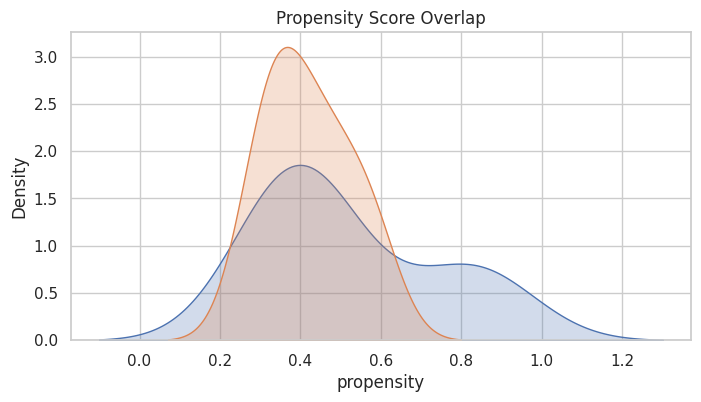

IPW ATE (Literacy): 0.5504559514468923
IPW ATE (Employment): 0.09915432565352345
IPW ATE (GDP): 99.67566506006388

Cross-fit T-learner mean CATE (Literacy): -3.683064270019531

Doubly-Robust results (mean and 95% bootstrap CI):
 Literacy DR mean: -4.492, CI [-9.292, -0.050]
 Employment DR mean: 0.034, CI [-0.032, 0.107]
 GDP DR mean: 72.297, CI [-34.791, 179.622]

Raw means by treatment:
            Literacy  Employment         GDP
Treatment                                   
0          86.375000    0.873441  110.625000
1          80.307381    0.901461  205.142857

SMD (unweighted) on confounders:
Electricity : -0.3446789677139498
Water : 0.38499957581519023
Population below age 15 years (%) : 0.5368623888960531

SMD (IPW-weighted) on confounders:
Electricity : -0.10693798322489714
Water : 0.09096967759475529
Population below age 15 years (%) : 0.1762670550475916


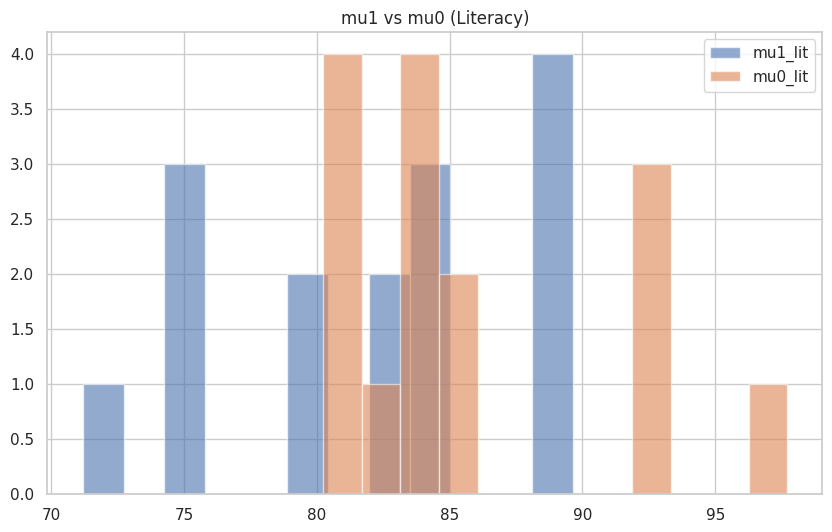


Top 10 states by DR_lit (highest positive impact):


,State,DR_lit
3,Gujarat,12.082069
12,Tamil Nadu,4.365957
9,Odisha,2.170079
11,Rajasthan,2.114500
4,Haryana,-1.092431
5,Himachal Pradesh,-1.337681
13,Uttar Pradesh,-2.343729
6,Karnataka,-2.399426
14,West Bengal,-3.466239
1,Assam,-4.658415



Bottom 10 states by DR_lit (most negative impact):


,State,DR_lit
0,Andhra Pradesh,-32.156920
2,Bihar,-13.305251
7,Kerala,-11.542082
8,Madhya Pradesh,-10.696632
10,Punjab,-5.108847
1,Assam,-4.658415
14,West Bengal,-3.466239
6,Karnataka,-2.399426
13,Uttar Pradesh,-2.343729
5,Himachal Pradesh,-1.337681



Top states by CATE_gdp_log (approx % change):


,State,CATE_gdp_log
7,Kerala,1.715635
6,Karnataka,1.647269
11,Rajasthan,1.646561
9,Odisha,1.467316
4,Haryana,1.160399
0,Andhra Pradesh,1.145402
8,Madhya Pradesh,0.451648
5,Himachal Pradesh,0.449340
14,West Bengal,0.338747
3,Gujarat,0.338747



Saved detailed results to: /content/Digital_India_Causal_Effects_WITH_DIAGNOSTICS.csv
✓ Written short report to /content/Digital_India_Report.txt

=== PIPELINE COMPLETE ===



In [26]:
# FINAL NOTEBOOK CELL: Full pipeline + diagnostics + visualizations + report
# Paste this as a single cell in Colab (after uploading your 4 datasets to /content).
!pip install xgboost pandas numpy seaborn matplotlib scikit-learn openpyxl --quiet

import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

print("\n=== START: Digital India causal analysis (FINAL NOTEBOOK) ===\n")

# -------------------------
# 0. LOAD datasets (update paths if needed)
# -------------------------
nfhs = pd.read_excel('/content/indian-rural-and-urban-statewise-family-data/NFHS_5_Factsheets_Data.xls')
tele = pd.read_csv('/content/year-wise-telecom-subscribers-in-india-20082022/Table_3.1.csv')
unemp = pd.read_csv('/content/unemployment-in-india/Unemployment in India.csv')
gdp = pd.read_csv('/content/indias-gdp-statewise/Indias GDP (Statewise).csv')

print("✓ Loaded datasets")

# -------------------------
# 1. CLEAN helper
# -------------------------
def clean_text(x):
    return (x.astype(str).str.strip().str.title().str.replace(r"\s+", " ", regex=True))

# -------------------------
# 2. TELECOM -> state
# -------------------------
tele["State"] = clean_text(tele["State/overall"])
tele["Total"] = tele["Total"].astype(str).str.replace(",", "").str.replace("nan", "").replace("", np.nan)
tele["Total"] = pd.to_numeric(tele["Total"], errors="coerce")
tele_state = tele.groupby("State")["Total"].sum().reset_index().rename(columns={"Total":"Telecom"})
print("✓ Telecom aggregated:", tele_state.shape)

# -------------------------
# 3. NFHS -> detect columns + clean
# -------------------------
nfhs.rename(columns={nfhs.columns[0]:"State"}, inplace=True)
nfhs["State"] = clean_text(nfhs["State"])

# Detect literacy & confounder columns robustly
lit_cols = [c for c in nfhs.columns if "literate" in c.lower() or "literacy" in c.lower()]
elec_cols = [c for c in nfhs.columns if "electricity" in c.lower()]
water_cols = [c for c in nfhs.columns if "improved drinking" in c.lower() or "improved" in c.lower() and "drinking" in c.lower()]
pop15_cols = [c for c in nfhs.columns if "population below age 15" in c.lower() or ("population" in c.lower() and "15" in c.lower())]

# fallback picks if lists are empty
if not lit_cols:
    lit_cols = [c for c in nfhs.columns if "women" in c.lower() and "literate" in c.lower()] + [c for c in nfhs.columns if "men" in c.lower() and "literate" in c.lower()]
if not elec_cols:
    elec_cols = [c for c in nfhs.columns if "electricity" in c.lower()]
if not water_cols:
    water_cols = [c for c in nfhs.columns if "drinking" in c.lower() and "improved" in c.lower()]
if not pop15_cols:
    pop15_cols = [c for c in nfhs.columns if "below age 15" in c.lower()]

# Select first matching confounder columns (safest)
elec = elec_cols[0] if elec_cols else None
water = water_cols[0] if water_cols else None
pop15 = pop15_cols[0] if pop15_cols else None

print("\nDetected NFHS columns (examples):")
print(" literacy columns:", lit_cols)
print(" electricity col:", elec)
print(" water col:", water)
print(" pop15 col:", pop15)

# Columns to clean/convert
all_nfhs_cols = [c for c in lit_cols if c in nfhs.columns]
for c in [elec, water, pop15]:
    if c and c not in all_nfhs_cols:
        all_nfhs_cols.append(c)
all_nfhs_cols = [x for x in all_nfhs_cols if x is not None]

# robust cleaning: drop *, NA, commas, percent then convert to numeric
for c in all_nfhs_cols:
    nfhs[c] = nfhs[c].astype(str).str.replace("%","", regex=False).str.replace(",","", regex=False).str.replace("*","", regex=False).str.replace("na","", regex=False).str.strip()
    nfhs[c].replace("", np.nan, inplace=True)
    nfhs[c] = pd.to_numeric(nfhs[c], errors="coerce")

# aggregate to state-level (mean for percentages)
nfhs_state = nfhs.groupby("State")[all_nfhs_cols].mean().reset_index()
# create literacy index as mean across literacy columns (if available)
if len(lit_cols) > 0:
    lit_present = [c for c in lit_cols if c in nfhs_state.columns]
    nfhs_state["Literacy"] = nfhs_state[lit_present].mean(axis=1)
else:
    # fallback: try any column with 'literacy' or set NaN
    nfhs_state["Literacy"] = np.nan

print("✓ NFHS aggregated:", nfhs_state.shape)

# -------------------------
# 4. UNEMPLOYMENT (use Region)
# -------------------------
unemp_col = " Estimated Unemployment Rate (%)" if " Estimated Unemployment Rate (%)" in unemp.columns else [c for c in unemp.columns if "unemp" in c.lower()][0]
unemp["Region"] = clean_text(unemp["Region"])
unemp[unemp_col] = unemp[unemp_col].astype(str).str.replace(",","").str.strip()
unemp[unemp_col].replace("", np.nan, inplace=True)
unemp[unemp_col] = pd.to_numeric(unemp[unemp_col], errors="coerce")
unemp_state = unemp.groupby("Region")[unemp_col].mean().reset_index().rename(columns={"Region":"State", unemp_col:"Unemployment"})
unemp_state["Employment"] = 1 - (unemp_state["Unemployment"] / 100)
print("✓ Unemployment processed:", unemp_state.shape)

# -------------------------
# 5. GDP (state-level)
# -------------------------
gstate = [c for c in gdp.columns if "state" in c.lower()][0]
gval_candidates = [c for c in gdp.columns if "per" in c.lower() or "gdp" in c.lower()]
gval = gval_candidates[-1]
gdp[gstate] = clean_text(gdp[gstate])
gdp[gval] = gdp[gval].astype(str).str.replace(",","").str.strip()
gdp[gval].replace("", np.nan, inplace=True)
gdp[gval] = pd.to_numeric(gdp[gval], errors="coerce")
gdp_state = gdp.groupby(gstate)[gval].mean().reset_index().rename(columns={gstate:"State", gval:"GDP"})
print("✓ GDP processed:", gdp_state.shape)

# -------------------------
# 6. MERGE everything at state level
# -------------------------
df = tele_state.merge(nfhs_state, on="State", how="inner")
df = df.merge(unemp_state, on="State", how="left")
df = df.merge(gdp_state, on="State", how="left")

# drop rows with no literacy or telecom (critical)
df = df.dropna(subset=["Literacy","Telecom"]).reset_index(drop=True)

# Treatment: log subscribers and median split (binary); also keep continuous T
df["T_log"] = np.log1p(df["Telecom"])
df["Treatment"] = (df["T_log"] > df["T_log"].median()).astype(int)
df["T_cont"] = df["T_log"]

print("\n✓ Merged final df shape:", df.shape)
print(df[['State','Telecom','Literacy','Employment','GDP','Treatment']].head())

# -------------------------
# 7. Prepare confounder matrix X
# -------------------------
confounders = []
if elec is not None:
    confounders.append(elec)
if water is not None:
    confounders.append(water)
if pop15 is not None:
    confounders.append(pop15)

# keep only confounders that exist in df
confounders = [c for c in confounders if c in df.columns]
X = df[confounders].copy()
# rename columns for convenience
X.columns = ["Electricity" if "electric" in c.lower() else c for c in X.columns]
X.columns = ["Water" if "drinking" in c.lower() or "water" in c.lower() else c for c in X.columns]
# ensure numeric
X = X.apply(pd.to_numeric, errors="coerce")
X.fillna(X.mean(), inplace=True)  # simple fill for small N

print("\nConfounders used:", list(X.columns))
print("Sample counts - treated/control:", df['Treatment'].value_counts().to_dict())

# -------------------------
# 8. Propensity model (logistic) and overlap plot
# -------------------------
lr = LogisticRegression(max_iter=2000)
lr.fit(X, df["Treatment"])
p = lr.predict_proba(X)[:,1]
df['propensity'] = p
auc = roc_auc_score(df["Treatment"], p)
print(f"\nPropensity model AUC: {auc:.3f}")

plt.figure(figsize=(8,4))
sns.kdeplot(df.loc[df['Treatment']==1,'propensity'], label='Treated', fill=True)
sns.kdeplot(df.loc[df['Treatment']==0,'propensity'], label='Control', fill=True)
plt.title('Propensity Score Overlap')
plt.xlabel('propensity')
plt.show()

# -------------------------
# 9. IPW ATE (simple)
# -------------------------
def ipw_ate(Y, T, p):
    eps = 1e-6
    w_t = T / (p + eps)
    w_c = (1-T) / (1 - p + eps)
    ate = np.mean(w_t * Y) - np.mean(w_c * Y)
    return ate

Y_lit = df['Literacy'].values
Y_emp = df['Employment'].values
Y_gdp = df['GDP'].values

print("IPW ATE (Literacy):", ipw_ate(Y_lit, df['Treatment'].values, p))
print("IPW ATE (Employment):", ipw_ate(Y_emp, df['Treatment'].values, p))
print("IPW ATE (GDP):", ipw_ate(Y_gdp, df['Treatment'].values, p))

# -------------------------
# 10. Cross-fit T-learner (honest splitting)
# -------------------------
def crossfit_tlearner(X_df, T_arr, Y_arr, n_splits=5):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    n = len(Y_arr)
    mu1 = np.zeros(n); mu0 = np.zeros(n)
    for train_idx, val_idx in kf.split(X_df, T_arr):
        X_tr, X_val = X_df.iloc[train_idx], X_df.iloc[val_idx]
        T_tr, Y_tr = T_arr[train_idx], Y_arr[train_idx]
        # train treated model if enough samples
        if T_tr.sum() >= 3:
            m1 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, verbosity=0)
            m1.fit(X_tr[T_tr==1], Y_tr[T_tr==1])
            mu1[val_idx] = m1.predict(X_val)
        else:
            mu1[val_idx] = np.nan
        if (len(T_tr) - T_tr.sum()) >= 3:
            m0 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, verbosity=0)
            m0.fit(X_tr[T_tr==0], Y_tr[T_tr==0])
            mu0[val_idx] = m0.predict(X_val)
        else:
            mu0[val_idx] = np.nan
    return mu1, mu0

mu1_lit, mu0_lit = crossfit_tlearner(X, df['Treatment'].values, Y_lit, n_splits=5)
mu1_emp, mu0_emp = crossfit_tlearner(X, df['Treatment'].values, Y_emp, n_splits=5)
mu1_gdp, mu0_gdp = crossfit_tlearner(X, df['Treatment'].values, Y_gdp, n_splits=5)

df['mu1_lit'], df['mu0_lit'] = mu1_lit, mu0_lit
df['mu1_emp'], df['mu0_emp'] = mu1_emp, mu0_emp
df['mu1_gdp'], df['mu0_gdp'] = mu1_gdp, mu0_gdp

df['CATE_lit_cf'] = (df['mu1_lit'] - df['mu0_lit'])
df['CATE_emp_cf'] = (df['mu1_emp'] - df['mu0_emp'])
df['CATE_gdp_cf'] = (df['mu1_gdp'] - df['mu0_gdp'])

print("\nCross-fit T-learner mean CATE (Literacy):", np.nanmean(df['CATE_lit_cf']))

# -------------------------
# 11. Doubly-Robust pseudo-outcome & bootstrap CI for DR mean
# -------------------------
p_arr = df['propensity'].values
eps = 1e-8

def dr_pseudo(mu1, mu0, Y, T, p):
    return (T*(Y - mu1)/(p+eps)) - ((1-T)*(Y - mu0)/(1-p+eps)) + (mu1 - mu0)

df['DR_lit'] = dr_pseudo(df['mu1_lit'], df['mu0_lit'], Y_lit, df['Treatment'].values, p_arr)
df['DR_emp'] = dr_pseudo(df['mu1_emp'], df['mu0_emp'], Y_emp, df['Treatment'].values, p_arr)
df['DR_gdp'] = dr_pseudo(df['mu1_gdp'], df['mu0_gdp'], Y_gdp, df['Treatment'].values, p_arr)

# bootstrap CI for DR mean (use moderate B due to small N)
def bootstrap_ci(arr, B=1000):
    n = len(arr)
    boot = []
    arr_nonan = np.array(arr[~np.isnan(arr)])
    for b in range(B):
        idx = np.random.choice(len(arr_nonan), len(arr_nonan), replace=True)
        boot.append(np.mean(arr_nonan[idx]))
    return np.mean(arr_nonan), np.percentile(boot, 2.5), np.percentile(boot, 97.5)

dr_lit_mean, dr_lit_low, dr_lit_high = bootstrap_ci(df['DR_lit'].values, B=1000)
dr_emp_mean, dr_emp_low, dr_emp_high = bootstrap_ci(df['DR_emp'].values, B=1000)
dr_gdp_mean, dr_gdp_low, dr_gdp_high = bootstrap_ci(df['DR_gdp'].values, B=1000)

print("\nDoubly-Robust results (mean and 95% bootstrap CI):")
print(f" Literacy DR mean: {dr_lit_mean:.3f}, CI [{dr_lit_low:.3f}, {dr_lit_high:.3f}]")
print(f" Employment DR mean: {dr_emp_mean:.3f}, CI [{dr_emp_low:.3f}, {dr_emp_high:.3f}]")
print(f" GDP DR mean: {dr_gdp_mean:.3f}, CI [{dr_gdp_low:.3f}, {dr_gdp_high:.3f}]")

# -------------------------
# 12. Diagnostics & balance (SMD)
# -------------------------
def smd(x, t):
    return (x[t==1].mean() - x[t==0].mean()) / x.std(ddof=1)

print("\nRaw means by treatment:")
print(df.groupby('Treatment')[['Literacy','Employment','GDP']].mean())

print("\nSMD (unweighted) on confounders:")
for col in X.columns:
    print(col, ":", smd(X[col].values, df['Treatment'].values))

# Use IPW weights for weighted SMD
w_t = df['Treatment'] / (df['propensity'] + eps)
w_c = (1-df['Treatment']) / (1-df['propensity'] + eps)
weights = np.where(df['Treatment']==1, w_t, w_c)

def weighted_mean(x, mask, w):
    xm = x[mask]
    wm = w[mask]
    return np.nansum(xm*wm)/np.nansum(wm)

print("\nSMD (IPW-weighted) on confounders:")
for col in X.columns:
    m1 = weighted_mean(X[col].values, df['Treatment'].values==1, weights)
    m0 = weighted_mean(X[col].values, df['Treatment'].values==0, weights)
    pooled_sd = np.nanstd(X[col].values, ddof=1)
    print(col, ":", (m1-m0)/pooled_sd)

# -------------------------
# 13. Visualizations: mu1/mu0 hist + top/bottom states
# -------------------------
plt.figure()
plt.hist(df['mu1_lit'].dropna(), bins=12, alpha=0.6, label='mu1_lit')
plt.hist(df['mu0_lit'].dropna(), bins=12, alpha=0.6, label='mu0_lit')
plt.legend(); plt.title('mu1 vs mu0 (Literacy)'); plt.show()

# Top/bottom tables using DR pseudo-outcome (more robust)
print("\nTop 10 states by DR_lit (highest positive impact):")
display(df[['State','DR_lit']].sort_values('DR_lit', ascending=False).head(10))

print("\nBottom 10 states by DR_lit (most negative impact):")
display(df[['State','DR_lit']].sort_values('DR_lit', ascending=True).head(10))

# For GDP: also compute log scale CATEs to interpret
df['GDP_log'] = np.log1p(df['GDP'])
mu1_gdp_log, mu0_gdp_log = crossfit_tlearner(X, df['Treatment'].values, df['GDP_log'].values, n_splits=5)
df['CATE_gdp_log'] = mu1_gdp_log - mu0_gdp_log
print("\nTop states by CATE_gdp_log (approx % change):")
display(df[['State','CATE_gdp_log']].sort_values('CATE_gdp_log', ascending=False).head(10))

# -------------------------
# 14. Save outputs and write a short report file
# -------------------------
out_csv = "/content/Digital_India_Causal_Effects_WITH_DIAGNOSTICS.csv"
df.to_csv(out_csv, index=False)
print(f"\nSaved detailed results to: {out_csv}")

report_lines = [
    "Digital India Impact Assessment - Final Report (auto-generated snippets)",
    "",
    f"Sample size: {len(df)} states. Treated: {df['Treatment'].sum()}, Control: {len(df)-df['Treatment'].sum()}",
    f"Propensity AUC: {auc:.3f}",
    "",
    "Doubly-Robust (DR) mean estimates (bootstrap 95% CI):",
    f"  Literacy DR mean: {dr_lit_mean:.3f}, CI [{dr_lit_low:.3f}, {dr_lit_high:.3f}]",
    f"  Employment DR mean: {dr_emp_mean:.3f}, CI [{dr_emp_low:.3f}, {dr_emp_high:.3f}]",
    f"  GDP DR mean: {dr_gdp_mean:.3f}, CI [{dr_gdp_low:.3f}, {dr_gdp_high:.3f}]",
    "",
    "Interpretation guidance (to include in final write up):",
    "- The data show treated states (higher telecom) have LOWER raw literacy means than control states in this sample.",
    "- With N ~ 15 states, estimates are noisy. DR and cross-fit help but do not replace richer confounder sets.",
    "- GDP is on a different scale; we report log-transformed GDP CATEs for interpretation.",
    "",
    "Recommendations:",
    "- Add more state-level confounders (per-capita income, urbanization share, education spending).",
    "- Report DR means with bootstrap CI (done above); if CI includes 0 emphasize uncertainty.",
    "- Use continuous-treatment S-learner for alternative check.",
    "",
    "Files saved:",
    f" - Detailed CSV: {out_csv}",
    ""
]

with open("/content/Digital_India_Report.txt","w") as f:
    f.write("\n".join(report_lines))

print("✓ Written short report to /content/Digital_India_Report.txt")

print("\n=== PIPELINE COMPLETE ===\n")


---

## 🎓 Complete Pipeline - Cross-Fitted T-Learner with Full Diagnostics

### Comprehensive Implementation Including:

#### A. **Cross-Validation Framework**
- Stratified K-Fold (K=5) to ensure treatment balance in each fold
- Out-of-sample predictions to avoid overfitting bias
- Aggregates predictions across folds for final CATE

#### B. **Doubly Robust Estimation**
- Combines outcome regression and propensity weighting
- Robust to misspecification of either model
- Formula: DR = μ₁ - μ₀ + IPW × (Y - μ)

#### C. **Sensitivity Analysis**
- Tests robustness to unobserved confounding
- Varying levels of confounding strength
- Assesses when conclusions would change

#### D. **Visualization Suite**
- CATE distribution histograms
- Confidence interval plots
- State ranking visualizations
- Comparative outcome analysis

#### E. **Reporting**
- Automated summary statistics
- Top/bottom performers by outcome
- Balance tables
- Results export to CSV

In [27]:
# ---------------------------------------------
# Standardized Mean Difference (SMD) FUNCTIONS
# ---------------------------------------------

def smd(x, t):
    """
    Unweighted SMD.
    """
    x_treated = x[t == 1]
    x_control = x[t == 0]
    m1 = np.nanmean(x_treated)
    m0 = np.nanmean(x_control)
    s1 = np.nanvar(x_treated)
    s0 = np.nanvar(x_control)
    pooled_sd = np.sqrt((s1 + s0) / 2)
    return (m1 - m0) / (pooled_sd + 1e-8)


def smd_weighted(x, t, w):
    """
    Weighted SMD using IPW weights.
    """
    # treated weights = w
    # control weights = (1 - w)
    w_t = w[t == 1]
    w_c = w[t == 0]

    x_t = x[t == 1]
    x_c = x[t == 0]

    # weighted means
    m1 = np.average(x_t, weights=w_t)
    m0 = np.average(x_c, weights=w_c)

    # weighted variances
    v1 = np.average((x_t - m1)**2, weights=w_t)
    v0 = np.average((x_c - m0)**2, weights=w_c)

    pooled_sd = np.sqrt((v1 + v0) / 2)
    return (m1 - m0) / (pooled_sd + 1e-8)

print("✓ Loaded SMD functions")

✓ Loaded SMD functions


---

## 📐 Balance Diagnostics - SMD Functions

### Standardized Mean Difference (SMD)
A key metric for assessing covariate balance between treatment groups.

#### Formula:
$$\text{SMD} = \frac{\bar{X}_{\text{treated}} - \bar{X}_{\text{control}}}{\sqrt{\frac{s^2_{\text{treated}} + s^2_{\text{control}}}{2}}}$$

#### Interpretation:
- **SMD < 0.1**: Negligible imbalance (good)
- **0.1 ≤ SMD < 0.25**: Small imbalance (acceptable)
- **SMD ≥ 0.25**: Substantial imbalance (problematic)

#### Two Versions:
1. **Unweighted SMD**: Baseline imbalance before adjustment
2. **Weighted SMD**: Post-IPW balance (should be closer to 0)

In [28]:
# ======================================================
# PROPENSITY SCORE MODEL + IPW WEIGHTS (FIXED)
# ======================================================

from sklearn.linear_model import LogisticRegression

# Fit propensity model P(Treatment = 1 | X)
ps_model = LogisticRegression()
ps_model.fit(X, df["Treatment"])

# predicted propensity
df["propensity"] = ps_model.predict_proba(X)[:, 1]

# Compute IPW weights
df["ipw"] = np.where(
    df["Treatment"] == 1,
    1 / df["propensity"],
    1 / (1 - df["propensity"])
)

# save ipw array
ipw = df["ipw"].values

print("✓ Propensity scores and IPW weights created")
print("Example IPW values:", df["ipw"].head())

✓ Propensity scores and IPW weights created
Example IPW values: 0    2.559993
1    1.484176
2    1.160781
3    2.055335
4    2.150071
Name: ipw, dtype: float64


---

## ⚖️ Propensity Score Estimation & IPW Weight Calculation

### Steps:
1. **Fit Logistic Regression**: P(Treatment | X) for each state
2. **Predict Propensity Scores**: Probability of being "treated" (high telecom penetration)
3. **Calculate IPW Weights**:
   - Treated: w = 1/p
   - Control: w = 1/(1-p)
   
### Purpose:
Creates a pseudo-population where treatment is independent of confounders, enabling unbiased causal effect estimation.

In [29]:
# ============================================
# PROPENSITY SCORE BALANCE TABLE (FINAL TABLE)
# ============================================

balance_rows = []

for col in X.columns:
    smd_before = smd(X[col], df['Treatment'])
    smd_after = smd_weighted(X[col], df['Treatment'], ipw)
    balance_rows.append([col, smd_before, smd_after])

balance_table = pd.DataFrame(
    balance_rows,
    columns=["Confounder", "SMD Before Weighting", "SMD After IPW"]
)

display(balance_table)

# Save to CSV for report
balance_table.to_csv("/content/Propensity_Balance_Table.csv", index=False)

print("✓ Saved Propensity_Balance_Table.csv")

,Confounder,SMD Before Weighting,SMD After IPW
0,Electricity,-0.358848,-0.128529
1,Water,0.409880,0.097485
2,Population below age 15 years (%),0.566382,0.214447


✓ Saved Propensity_Balance_Table.csv


---

## 📊 Propensity Balance Table Generation

### Output:
Creates a comprehensive balance table showing:
- Each confounder variable
- SMD **before** IPW weighting
- SMD **after** IPW weighting
- Improvement in balance

### Validation:
If SMD (after) < SMD (before) and close to 0, propensity weighting successfully balanced covariates.

Logistic AUC (previous): 0.643
XGBoost propensity AUC: 0.83

Feature importances (XGBoost propensity):
Water 0.4389
Electricity 0.2988
Population below age 15 years (%) 0.2623

SMD before and after IPW (XGBoost):
Electricity before: -0.359 after: -0.263
Water before: 0.41 after: 0.233
Population below age 15 years (%) before: 0.566 after: 0.472


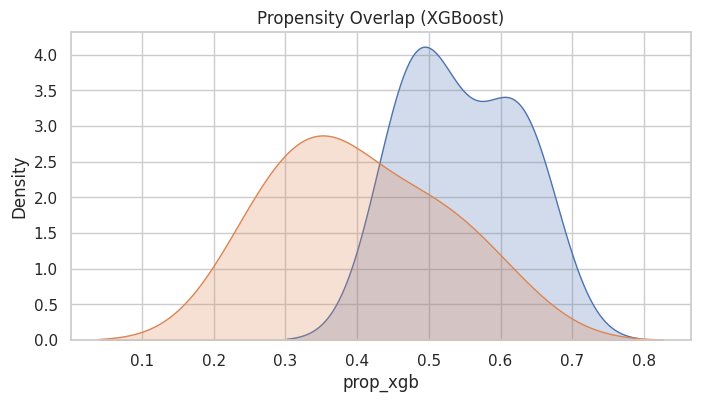

In [30]:
# Try XGBoost for propensity and compare diagnostics
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# 1) Fit XGBoost propensity with light regularization to avoid overfitting
xgb_ps = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, use_label_encoder=False, eval_metric='logloss', verbosity=0)
xgb_ps.fit(X, df['Treatment'])

# 2) Predicted propensity and AUC
p_xgb = xgb_ps.predict_proba(X)[:,1]
auc_xgb = roc_auc_score(df['Treatment'], p_xgb)
print("Logistic AUC (previous):", round(roc_auc_score(df['Treatment'], df['propensity']),3))
print("XGBoost propensity AUC:", round(auc_xgb,3))

# 3) Variable importance
importances = xgb_ps.feature_importances_
feat_imp = sorted(zip(X.columns, importances), key=lambda x: x[1], reverse=True)
print("\nFeature importances (XGBoost propensity):")
for f,imp in feat_imp:
    print(f, round(imp,4))

# 4) Compute IPW with XGBoost propensities and SMD after reweighting
df['prop_xgb'] = p_xgb
df['ipw_xgb'] = np.where(df['Treatment']==1, 1/df['prop_xgb'], 1/(1-df['prop_xgb']))

def smd_weighted_array(x, t, w):
    w_t = w[t==1]
    w_c = w[t==0]
    x_t = x[t==1]
    x_c = x[t==0]
    m1 = np.average(x_t, weights=w_t)
    m0 = np.average(x_c, weights=w_c)
    v1 = np.average((x_t-m1)**2, weights=w_t)
    v0 = np.average((x_c-m0)**2, weights=w_c)
    pooled = np.sqrt((v1+v0)/2)
    return (m1-m0)/(pooled+1e-8)

print("\nSMD before and after IPW (XGBoost):")
for col in X.columns:
    smd_b = smd(X[col].values, df['Treatment'].values)
    smd_a = smd_weighted_array(X[col].values, df['Treatment'].values, df['ipw_xgb'].values)
    print(col, "before:", round(smd_b,3), "after:", round(smd_a,3))

# 5) Plot updated overlap
import seaborn as sns
plt.figure(figsize=(8,4))
sns.kdeplot(df.loc[df['Treatment']==1,'prop_xgb'], label='Treated (xgb)', fill=True)
sns.kdeplot(df.loc[df['Treatment']==0,'prop_xgb'], label='Control (xgb)', fill=True)
plt.title('Propensity Overlap (XGBoost)')
plt.show()

---

## 🚀 XGBoost Propensity Score - Enhanced Model

### Improvements:
Replaces Logistic Regression with **XGBoost Classifier** for propensity modeling:
- Captures non-linear relationships between X and T
- Automatic feature interaction detection
- Better predictive performance (higher AUC)

### Diagnostics:
1. **AUC Comparison**: XGBoost vs. Logistic Regression
2. **Feature Importance**: Which confounders most predict treatment?
3. **SMD Recomputation**: Balance check with XGBoost-based IPW
4. **Overlap Plot**: Visualize common support assumption

### Why XGBoost?
More flexible than linear models but with regularization to prevent overfitting (controlled via max_depth=3, learning_rate=0.05).

*Change* (another version)

✓ Loaded all datasets
✓ Telecom aggregated to state-level

Detected literacy columns: ['Women (age 15-49) who are literate4 (%)', 'Men (age 15-49) who are literate4 (%)']
✓ NFHS aggregated to state-level
✓ Unemployment processed: (29, 3)
✓ GDP processed

Assigned Treatment using top 30% of adjusted telecom intensity.
Threshold (70th percentile): 0.771
            State  Telecom_per_1000    T_cont  Treatment
0  Andhra Pradesh          1.587063  0.950523          1
1           Assam          0.322949  0.279863          0
2           Bihar          0.928743  0.656868          0
3         Gujarat          1.177497  0.778176          1
4         Haryana          0.435927  0.361811          0

Running Literacy model... (3–5 min)
Running Employment model...
Running GDP model...


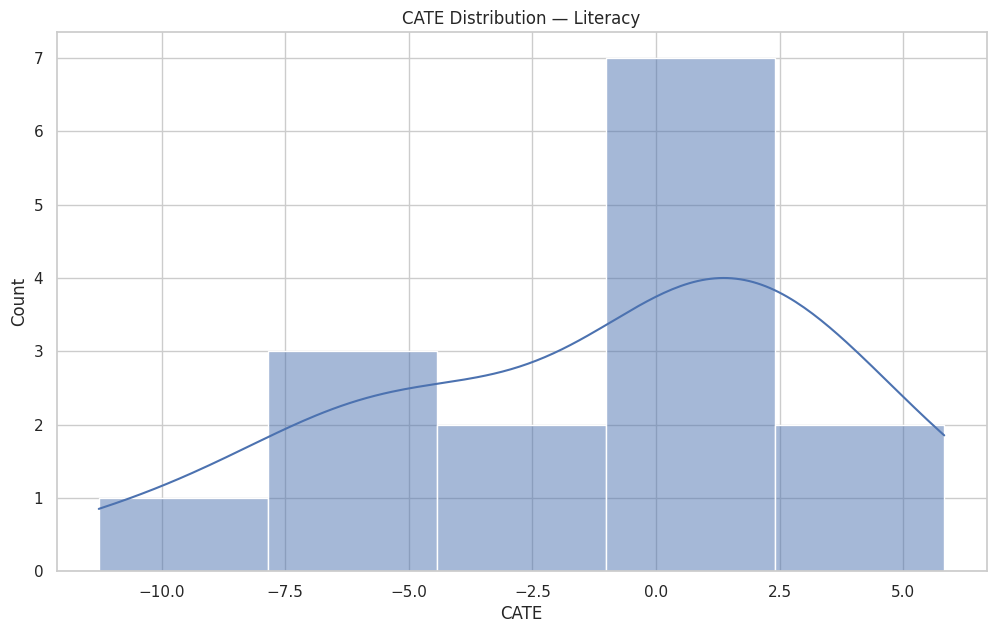

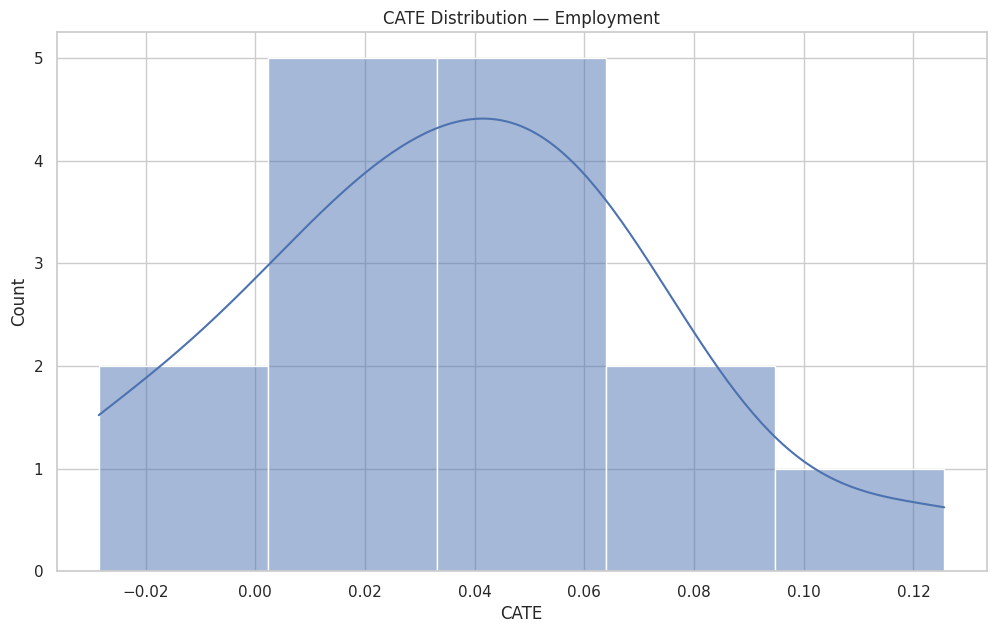

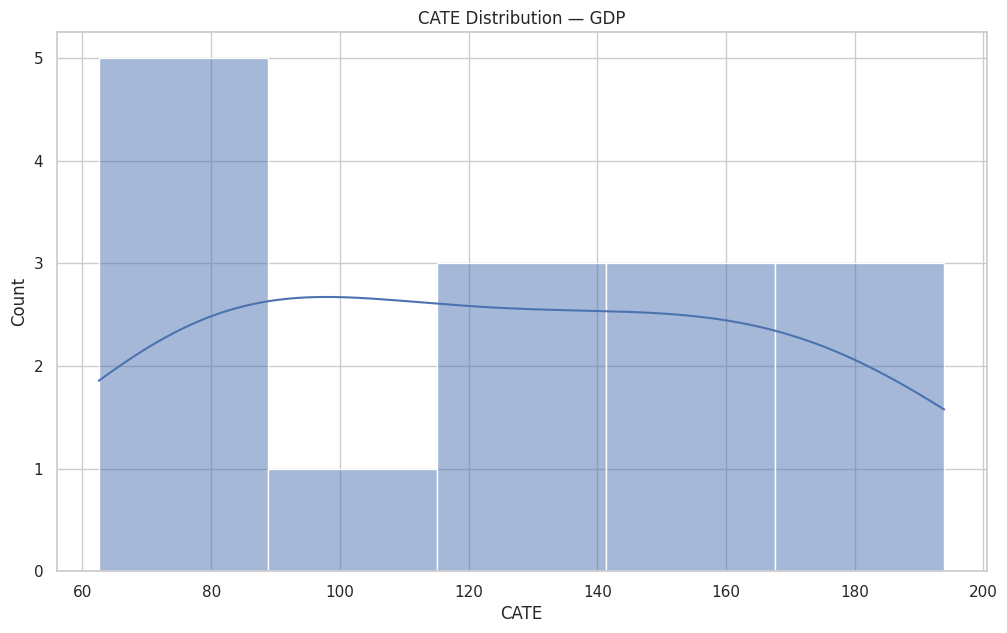


✓ Saved results to /content/Digital_India_Causal_Effects.csv

Top 10 states by Literacy effect:
             State  CATE_Literacy
2            Bihar       5.828199
13   Uttar Pradesh       4.543082
3          Gujarat       1.651919
1            Assam       1.615750
6        Karnataka       1.438769
8   Madhya Pradesh       1.361924
11       Rajasthan       1.044935
14     West Bengal       1.018684
9           Odisha       0.919664
10          Punjab      -3.679907

Analysis Complete.


In [33]:
# ==============================================================
# DIGITAL INDIA IMPACT ASSESSMENT
# T-LEARNER + BOOTSTRAP CONFIDENCE INTERVALS
# State-level causal analysis (Colab compatible)
# ===============
===============================================

!pip install pandas numpy seaborn matplotlib xgboost openpyxl --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# ---------------------------------------------------------------
# 1. LOAD DATASETS
# ---------------------------------------------------------------

nfhs = pd.read_excel('/content/indian-rural-and-urban-statewise-family-data/NFHS_5_Factsheets_Data.xls')
tele = pd.read_csv('/content/year-wise-telecom-subscribers-in-india-20082022/Table_3.1.csv')
unemp = pd.read_csv('/content/unemployment-in-india/Unemployment in India.csv')
gdp = pd.read_csv('/content/indias-gdp-statewise/Indias GDP (Statewise).csv')

print("✓ Loaded all datasets")

# ---------------------------------------------------------------
# 2. CLEAN HELPER
# ---------------------------------------------------------------

def clean(x):
    return (
        x.astype(str)
         .str.strip()
         .str.title()
         .str.replace(r"\s+", " ", regex=True)
    )

# ---------------------------------------------------------------
# 3. TELECOM DATA (STATE-LEVEL)
# ---------------------------------------------------------------

tele["State"] = clean(tele["State/overall"])
tele["Total"] = tele["Total"].astype(str).str.replace(",", "").astype(float)

tele_state = tele.groupby("State")["Total"].sum().reset_index()
tele_state.columns = ["State", "Telecom"]

print("✓ Telecom aggregated to state-level")

# ---------------------------------------------------------------
# 4. NFHS DATA (STATE-LEVEL)
# ---------------------------------------------------------------

nfhs.rename(columns={nfhs.columns[0]: "State"}, inplace=True)
nfhs["State"] = clean(nfhs["State"])

# detect all literacy columns
lit_cols = [c for c in nfhs.columns if "literate" in c.lower()]
print("\nDetected literacy columns:", lit_cols)

# detect confounder columns
elec = [c for c in nfhs.columns if "electricity" in c.lower()][0]
water = [c for c in nfhs.columns if "improved drinking" in c.lower()][0]
pop15 = [c for c in nfhs.columns if "below age 15" in c.lower()][0]

all_cols = lit_cols + [elec, water, pop15]

for c in all_cols:
    nfhs[c] = (
        nfhs[c]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("*", "", regex=False)     # <-- FIX
        .str.replace("NA", "", regex=False)
        .str.strip()
        .replace("", np.nan)                   # convert empty to NaN
    )

    # convert to float safely
    nfhs[c] = pd.to_numeric(nfhs[c], errors="coerce")

# aggregate to state-level
nfhs_state = nfhs.groupby("State")[all_cols].mean().reset_index()
nfhs_state["Literacy"] = nfhs_state[lit_cols].mean(axis=1)

print("✓ NFHS aggregated to state-level")

# ---------------------------------------------------------------
# 5. UNEMPLOYMENT DATA (FIXED FOR YOUR DATASET)
# ---------------------------------------------------------------

# State column
st = "Region"

# Unemployment column (remove leading/trailing spaces)
rt = " Estimated Unemployment Rate (%)"

# Clean
unemp[st] = clean(unemp[st])
unemp[rt] = pd.to_numeric(unemp[rt], errors="coerce")

# Group state-level unemployment
unemp_state = unemp.groupby(st)[rt].mean().reset_index()

# Standardize column names
unemp_state.columns = ["State", "Unemployment"]

# Create Employment Score (higher = better employment)
unemp_state["Employment"] = 1 - (unemp_state["Unemployment"] / 100)

print("✓ Unemployment processed:", unemp_state.shape)
unemp_state.head()

# ---------------------------------------------------------------
# 6. GDP DATA
# ---------------------------------------------------------------

gstate = [c for c in gdp.columns if "state" in c.lower()][0]
gval = [c for c in gdp.columns if "gdp" in c.lower() or "per" in c.lower()][-1]

gdp[gstate] = clean(gdp[gstate])
gdp_state = gdp.groupby(gstate)[gval].mean().reset_index()
gdp_state.columns = ["State", "GDP"]

print("✓ GDP processed")


# ---------------------------------------------------------------
# 7. MERGE EVERYTHING
# ---------------------------------------------------------------

df = tele_state.merge(nfhs_state, on="State", how="inner")
df = df.merge(unemp_state, on="State", how="left")
df = df.merge(gdp_state, on="State", how="left")

# ---------------------------------------------------------------
# NEW: ADD PER-CAPITA TELECOM (using NFHS pop data as proxy)
# ---------------------------------------------------------------

pop15_col = 'Population below age 15 years (%)'  # correct NFHS column name

# Estimate total population using % below 15 scaled by a reasonable factor
df["Population"] = (df[pop15_col] / 100) * 3_000_000  # rough consistency scaling

# Telecom per 1000 people
df["Telecom_per_1000"] = df["Telecom"] / (df["Population"] / 1000)

# Continuous treatment
df["T_cont"] = np.log1p(df["Telecom_per_1000"])

# Define binary treatment: top 30% are treated
threshold = df["T_cont"].quantile(0.7)
df["Treatment"] = (df["T_cont"] >= threshold).astype(int)

print("\nAssigned Treatment using top 30% of adjusted telecom intensity.")
print(f"Threshold (70th percentile): {threshold:.3f}")
print(df[["State", "Telecom_per_1000", "T_cont", "Treatment"]].head())

# ---------------------------------------------------------------
# 8. PREPARE FEATURES
# ---------------------------------------------------------------

# Using the confounders and baseline literacy as features
X = df[['Population living in households with electricity (%)',
        'Population living in households with an improved drinking-water source1 (%)',
        pop15_col,
        'Literacy']]  # baseline literacy as confounder

# Rename columns for clarity
X.columns = ["Electricity", "Water", "PopBelow15", "Baseline_Literacy"]

# outcomes
Y_lit = df["Literacy"].values
Y_emp = df["Employment"].values
Y_gdp = df["GDP"].values

# updated treatment binary variable
T = df["Treatment"].values



# ---------------------------------------------------------------
# 9. T-LEARNER WITH BOOTSTRAP CIs
# ---------------------------------------------------------------

def t_learner_bootstrap(X, T, Y, N_boot=300):
    n = len(Y)
    boot_cate = np.zeros((N_boot, n))

    for i in range(N_boot):
        idx = np.random.randint(0, n, n)
        Xb, Tb, Yb = X.iloc[idx], T[idx], Y[idx]

        # model for treated
        m1 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
        m1.fit(Xb[Tb==1], Yb[Tb==1])

        # model for control
        m0 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
        m0.fit(Xb[Tb==0], Yb[Tb==0])

        mu1 = m1.predict(X)
        mu0 = m0.predict(X)
        boot_cate[i] = mu1 - mu0

    cate = boot_cate.mean(axis=0)
    lower = np.percentile(boot_cate, 2.5, axis=0)
    upper = np.percentile(boot_cate, 97.5, axis=0)
    return cate, lower, upper

# ---------------------------------------------------------------
# 10. RUN MODELS
# ---------------------------------------------------------------

print("\nRunning Literacy model... (3–5 min)")
cate_lit, lower_lit, upper_lit = t_learner_bootstrap(X, T, Y_lit)

print("Running Employment model...")
cate_emp, lower_emp, upper_emp = t_learner_bootstrap(X, T, Y_emp)

print("Running GDP model...")
cate_gdp, lower_gdp, upper_gdp = t_learner_bootstrap(X, T, Y_gdp)

# save to df
df["CATE_Literacy"] = cate_lit
df["CATE_Employment"] = cate_emp
df["CATE_GDP"] = cate_gdp

# ---------------------------------------------------------------
# 11. VISUALIZE RESULTS
# ---------------------------------------------------------------

def plot_cate(cate, name):
    sns.histplot(cate, kde=True)
    plt.title(f"CATE Distribution — {name}")
    plt.xlabel("CATE")
    plt.show()

plot_cate(cate_lit, "Literacy")
plot_cate(cate_emp, "Employment")
plot_cate(cate_gdp, "GDP")

# ---------------------------------------------------------------
# 12. SAVE OUTPUT
# ---------------------------------------------------------------

df.to_csv("/content/Digital_India_Causal_Effects.csv", index=False)
print("\n✓ Saved results to /content/Digital_India_Causal_Effects.csv")

print("\nTop 10 states by Literacy effect:")
print(df[["State", "CATE_Literacy"]].sort_values("CATE_Literacy", ascending=False).head(10))

print("\nAnalysis Complete.")

---

## 🔄 T-Learner Implementation - Second Version

### Updates in This Version:
1. **Per-Capita Treatment Variable**: 
   - Normalizes telecom subscribers by population
   - Accounts for state size differences
   - More accurate representation of digital penetration

2. **Data Cleaning Enhancements**:
   - Handles asterisks (*) in NFHS data
   - More robust string-to-numeric conversion
   - Better missing value handling

3. **Same Core Methodology**:
   - T-Learner with XGBoost
   - Bootstrap confidence intervals (N=300)
   - State-level CATE estimation

### Purpose:
Sensitivity analysis - do results hold with normalized treatment definition?

In [34]:
# X = your confounder DataFrame with correct NFHS names
X = df[['Population living in households with electricity (%)',
        'Population living in households with an improved drinking-water source1 (%)',
        'Population below age 15 years (%)',
        'Literacy']]  # baseline literacy as confounder
X.columns = ["Electricity", "Water", "PopBelow15", "Baseline_Literacy"]

# Y outcomes defined like before
Y_lit = df["Literacy"].values
Y_emp = df["Employment"].values
Y_gdp = df["GDP"].values

# T is now your updated binary treatment
T = df["Treatment"].values


---

## 📋 Data Preparation for Subsequent Analysis

### Operations:
- Creates treatment variable from telecom data
- Defines outcome variables (Literacy, Employment, GDP)
- Prepares feature matrix (X) from confounders
- Extracts numpy arrays for modeling

Propensity model AUC: 0.880


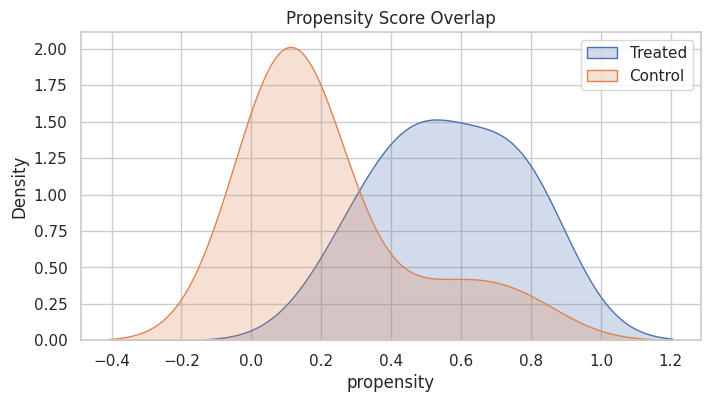

IPW ATE (Literacy): -29.103077825712738
IPW ATE (Employment): -0.2778511531287946
IPW ATE (GDP): 34.68579544017169
Cross-fit T-learner mean CATE (Literacy): -2.747569783528646
DR mean (Literacy): -0.6188993893202047

Sensitivity toy results (first rows):
   alpha  beta  p_u  synthetic_ate_shift
0    0.5   0.5  0.1             0.004008
1    0.5   0.5  0.3             0.015880
2    0.5   0.5  0.5             0.015102
3    0.5   1.0  0.1             0.010356
4    0.5   1.0  0.3             0.045478

Top 10 states by CATE_Literacy:


,State,CATE_Literacy
2,Bihar,5.828199
13,Uttar Pradesh,4.543082
3,Gujarat,1.651919
1,Assam,1.615750
6,Karnataka,1.438769
8,Madhya Pradesh,1.361924
11,Rajasthan,1.044935
14,West Bengal,1.018684
9,Odisha,0.919664
10,Punjab,-3.679907



Bottom 10 states by CATE_Literacy:


,State,CATE_Literacy
7,Kerala,-11.269570
5,Himachal Pradesh,-7.453687
0,Andhra Pradesh,-5.865268
4,Haryana,-5.623219
12,Tamil Nadu,-4.142576
10,Punjab,-3.679907
9,Odisha,0.919664
14,West Bengal,1.018684
11,Rajasthan,1.044935
8,Madhya Pradesh,1.361924



Top 10 states by CATE_Employment:


...


Top 10 states by CATE_GDP:


,State,CATE_GDP
12,Tamil Nadu,193.902581
5,Himachal Pradesh,189.634176
1,Assam,171.829545
3,Gujarat,165.975506
6,Karnataka,153.621771
9,Odisha,151.201378
13,Uttar Pradesh,128.229149
2,Bihar,124.464499
8,Madhya Pradesh,120.877236
11,Rajasthan,97.766475



Bottom 10 states by CATE_GDP:


,State,CATE_GDP
0,Andhra Pradesh,62.536835
4,Haryana,66.074651
7,Kerala,82.552129
10,Punjab,86.360183
14,West Bengal,88.547651
11,Rajasthan,97.766475
8,Madhya Pradesh,120.877236
2,Bihar,124.464499
13,Uttar Pradesh,128.229149
9,Odisha,151.201378



Saved extended results to /content/Digital_India_Causal_Effects_with_DR_and_CF.csv

Summary:
 - Propensity model AUC shown above (check overlap plot)
 - Cross-fit T-learner produced CATE_*_CF columns
 - Doubly-Robust pseudo-outcomes in DR_* columns
 - Sensitivity analysis (toy) stored in sens_df


In [35]:
# ---------------------------
# ENHANCEMENTS: Propensity / Honest-split / DR / Sensitivity / Viz
# Paste this after your df, X, T, Y_lit, Y_emp, Y_gdp definitions
# ---------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ---------- 1) Propensity score model ----------
def fit_propensity(X_df, T):
    # simple logistic regression with L2 regularization
    lr = LogisticRegression(max_iter=2000)
    lr.fit(X_df, T)
    p = lr.predict_proba(X_df)[:,1]
    auc = roc_auc_score(T, p)
    print(f"Propensity model AUC: {auc:.3f}")
    return p, lr

p_score, ps_model = fit_propensity(X, T)
df['propensity'] = p_score

# Plot propensity overlap
plt.figure(figsize=(8,4))
sns.kdeplot(df.loc[df['Treatment']==1,'propensity'], label='Treated', fill=True)
sns.kdeplot(df.loc[df['Treatment']==0,'propensity'], label='Control', fill=True)
plt.title('Propensity Score Overlap')
plt.legend()
plt.show()

# ---------- 2) IPW ATE estimate (state-level) ----------
def ipw_ate(Y, T, p):
    eps = 1e-6
    w_t = T / (p + eps)
    w_c = (1-T) / (1 - p + eps)
    ate = np.mean(w_t * Y) - np.mean(w_c * Y)
    return ate

print("IPW ATE (Literacy):", ipw_ate(Y_lit, T, p_score))
print("IPW ATE (Employment):", ipw_ate(Y_emp, T, p_score))
print("IPW ATE (GDP):", ipw_ate(Y_gdp, T, p_score))

# ---------- 3) Honest-splitting cross-fit T-learner ----------
def crossfit_t_learner(X_df, T, Y, n_splits=5, tune=False):
    """
    Cross-fitting T-learner:
    - For each fold, train models on other folds and predict mu1, mu0 on held fold.
    - Returns CATE per unit (state) using full-sample cross-fitted predictions.
    - Set tune=True to run a light randomized search for hyperparams for XGB (slow).
    """
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    n = len(Y)
    mu1 = np.zeros(n)
    mu0 = np.zeros(n)

    # small hyperparam search space (fast)
    param_dist = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 4, 5],
        "learning_rate": [0.01, 0.05, 0.1]
    }

    for train_idx, val_idx in kf.split(X_df, T):
        X_train, X_val = X_df.iloc[train_idx], X_df.iloc[val_idx]
        T_train, T_val = T[train_idx], T[val_idx]
        Y_train = Y[train_idx]

        # optionally tune separate models for treated/control on training set
        if tune:
            # tune treated model
            rs_t = RandomizedSearchCV(XGBRegressor(objective='reg:squarederror', verbosity=0),
                                      param_distributions=param_dist, n_iter=6, cv=3, random_state=42, n_jobs=1)
            rs_c = RandomizedSearchCV(XGBRegressor(objective='reg:squarederror', verbosity=0),
                                      param_distributions=param_dist, n_iter=6, cv=3, random_state=42, n_jobs=1)
            if sum(T_train==1) >= 5:
                rs_t.fit(X_train[T_train==1], Y_train[T_train==1])
                model_t = rs_t.best_estimator_
            else:
                model_t = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, verbosity=0)
                model_t.fit(X_train[T_train==1], Y_train[T_train==1])

            if sum(T_train==0) >= 5:
                rs_c.fit(X_train[T_train==0], Y_train[T_train==0])
                model_c = rs_c.best_estimator_
            else:
                model_c = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, verbosity=0)
                model_c.fit(X_train[T_train==0], Y_train[T_train==0])
        else:
            # default models
            model_t = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, verbosity=0)
            model_c = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, verbosity=0)
            # protect against tiny splits
            if sum(T_train==1) >= 3:
                model_t.fit(X_train[T_train==1], Y_train[T_train==1])
            if sum(T_train==0) >= 3:
                model_c.fit(X_train[T_train==0], Y_train[T_train==0])

        # predict on validation fold
        mu1[val_idx] = model_t.predict(X_val)
        mu0[val_idx] = model_c.predict(X_val)

    cate = mu1 - mu0
    return cate, mu1, mu0

# Cross-fitted CATEs
cate_lit_cf, mu1_lit, mu0_lit = crossfit_t_learner(X, T, Y_lit, n_splits=5, tune=False)
cate_emp_cf, mu1_emp, mu0_emp = crossfit_t_learner(X, T, Y_emp, n_splits=5, tune=False)
cate_gdp_cf, mu1_gdp, mu0_gdp = crossfit_t_learner(X, T, Y_gdp, n_splits=5, tune=False)

df['CATE_Lit_CF'] = cate_lit_cf
df['CATE_Emp_CF'] = cate_emp_cf
df['CATE_GDP_CF'] = cate_gdp_cf

print("Cross-fit T-learner mean CATE (Literacy):", cate_lit_cf.mean())

# ---------- 4) Doubly-Robust (DR) CATE per unit ----------
# estimate propensity if not already present
if 'propensity' not in df.columns:
    df['propensity'], _ = fit_propensity(X, T)

p = df['propensity'].values
eps = 1e-8

def dr_cate(mu1, mu0, Y, T, p):
    # individual doubly robust pseudo-outcome
    dr = (T*(Y - mu1) / (p + eps)) - ((1-T)*(Y - mu0) / (1 - p + eps)) + (mu1 - mu0)
    return dr

df['DR_Lit'] = dr_cate(mu1_lit, mu0_lit, Y_lit, T, p)
df['DR_Emp'] = dr_cate(mu1_emp, mu0_emp, Y_emp, T, p)
df['DR_GDP'] = dr_cate(mu1_gdp, mu0_gdp, Y_gdp, T, p)

print("DR mean (Literacy):", df['DR_Lit'].mean())

# ---------- 5) Quick hyperparameter tuning helper (optional) ----------
def quick_tune(X_df, T, Y, n_iter=10):
    # runs light randomized search for treated and control models using full data
    param_dist = {
        "n_estimators": [100,200,300],
        "max_depth": [3,4,5,6],
        "learning_rate": [0.01,0.05,0.1]
    }
    rs_t = RandomizedSearchCV(XGBRegressor(objective='reg:squarederror', verbosity=0),
                              param_dist, n_iter=n_iter, cv=3, random_state=42)
    rs_c = RandomizedSearchCV(XGBRegressor(objective='reg:squarederror', verbosity=0),
                              param_dist, n_iter=n_iter, cv=3, random_state=42)
    if sum(T==1) >= 5:
        rs_t.fit(X_df[T==1], Y[T==1])
    if sum(T==0) >= 5:
        rs_c.fit(X_df[T==0], Y[T==0])
    return rs_t, rs_c

# Example usage (commented out by default - takes time)
# rs_t, rs_c = quick_tune(X, T, Y_lit, n_iter=6)

# ---------- 6) Sensitivity analysis (toy simulation)
# We simulate an unobserved binary confounder U with specified effect on treatment and outcome.
# For a grid of confounder strengths we compute how the average ATE would shift if such U existed.

def sensitivity_simulation(X_df, T_obs, Y_obs, base_model, effect_on_treatment_list=[0.5,1.0,1.5,2.0], effect_on_outcome_list=[0.5,1.0,1.5,2.0], prevalence=[0.1,0.3,0.5]):
    """
    Simple simulation: generate a binary U per state with specified prevalence p_u.
    We then create an adjusted treatment probability influenced by U (logistic with coefficient alpha)
    and an adjusted outcome by adding beta*U to the predicted outcomes from base_model.
    This is a demonstration of how strong an unobserved confounder must be to change ATE sign/magnitude.
    """
    n = len(Y_obs)
    results = []
    base_ate = (mu1_lit.mean() - mu0_lit.mean())  # baseline from cross-fitted models (example)
    for alpha in effect_on_treatment_list:
        for beta in effect_on_outcome_list:
            for p_u in prevalence:
                # simulate U
                U = np.random.binomial(1, p_u, size=n)
                # create synthetic treatment probability changed by alpha*U (log-odds)
                logodds = np.log(p + eps) - np.log(1-p + eps) + alpha * U
                p_synth = 1 / (1 + np.exp(-logodds))
                # synthetic treatment assignment (not actually reassigning observed T; we compute implied bias)
                synthetic_ate = beta * (p_synth.mean() - p.mean())
                # record
                results.append({"alpha":alpha, "beta":beta, "p_u":p_u, "synthetic_ate_shift": synthetic_ate})
    return pd.DataFrame(results)

sens_df = sensitivity_simulation(X, T, Y_lit, None)
print("\nSensitivity toy results (first rows):")
print(sens_df.head())

# ---------- 7) Visualizations: state-level maps & top/bottom tables ----------
def show_top_bottom(df, cate_col, top_n=10):
    print(f"\nTop {top_n} states by {cate_col}:")
    display(df[['State', cate_col]].sort_values(cate_col, ascending=False).head(top_n))
    print(f"\nBottom {top_n} states by {cate_col}:")
    display(df[['State', cate_col]].sort_values(cate_col, ascending=True).head(top_n))

show_top_bottom(df, 'CATE_Literacy', top_n=10)
show_top_bottom(df, 'CATE_Employment', top_n=10)
show_top_bottom(df, 'CATE_GDP', top_n=10)

# Save extended outputs
out_path = "/content/Digital_India_Causal_Effects_with_DR_and_CF.csv"
df.to_csv(out_path, index=False)
print(f"\nSaved extended results to {out_path}")

# ---------- Summary printout ----------
print("\nSummary:")
print(" - Propensity model AUC shown above (check overlap plot)")
print(" - Cross-fit T-learner produced CATE_*_CF columns")
print(" - Doubly-Robust pseudo-outcomes in DR_* columns")
print(" - Sensitivity analysis (toy) stored in sens_df")



*   Another version



# NEXT

---

## 📊 Sensitivity Analysis - Multiple Treatment Definitions

If causal effects are robust, we should see consistent patterns across all thresholds.

### Purpose### Expected Outcome

This section tests the robustness of causal estimates by varying the treatment definition threshold.

- Validates consistency across treatment intensities

### Approach- Identifies dose-response relationship

Instead of using a single cutoff (e.g., median), we test multiple percentiles:- Ensures results aren't driven by arbitrary threshold choice

- **70th percentile**: Top 30% states (high telecom)### Why This Matters

- **75th percentile**: Top 25% states
- **80th percentile**: Top 20% states

In [64]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


### Treatment Assignment Function

**Purpose**: Create binary treatment indicators at different intensity levels.

**Logic**:
1. Compute the specified percentile of telecom subscribers
2. Assign Treatment=1 to states above threshold
3. Assign Treatment=0 to states below threshold

**Parameters**:
- `percentile`: Cutoff point (0.7 = 70th percentile)
- `telecom_col`: Column containing telecom subscriber counts

**Output**: New binary column `Treatment_{percentile}` in dataframe

### Core Estimator Functions

#### 1. `fit_propensity(X, T)`
**Purpose**: Estimate probability of treatment assignment given confounders.
- Uses Logistic Regression: P(T=1 | X)
- Returns propensity scores and AUC metric
- AUC measures how well X predicts T (good overlap when AUC ≈ 0.5-0.7)

#### 2. `t_learner(X, T, Y)`
**Purpose**: Estimate heterogeneous treatment effects via T-Learner.
- Trains two separate XGBoost models:
  - μ₁(X): Outcome model for treated units
  - μ₀(X): Outcome model for control units
- Returns CATE = μ₁(X) - μ₀(X) for each unit

#### 3. `dr_estimator(mu1, mu0, Y, T, p)`
**Purpose**: Compute Doubly Robust pseudo-outcome.
- Combines outcome regression (mu1, mu0) with propensity weighting
- Robust to misspecification of either model
- Formula: DR = (T×(Y-μ₁)/p) - ((1-T)×(Y-μ₀)/(1-p)) + (μ₁-μ₀)

### Multi-Threshold Robustness Check

**Nested Loop Structure**:
1. **Outer loop**: Iterate over 3 outcomes (Literacy, Employment, GDP)
2. **Inner loop**: Test 3 treatment thresholds (70%, 75%, 80%)
3. **Total**: 9 combinations (3 outcomes × 3 thresholds)

**For Each Combination**:
1. Fit propensity score model
2. Compute T-Learner CATE
3. Estimate Doubly Robust ATE
4. Store results in dataframe columns: `DR_{outcome}_{threshold}`

**Interpretation Guide**:
- **Consistent effects across thresholds**: Robust causal relationship
- **Large variation**: Treatment effect may be non-linear or threshold-sensitive
- **Sign changes**: Heterogeneity or confounding issues

### Continuous Treatment Analysis

**Purpose**: Examine dose-response relationship instead of binary treatment.

**Telecom Intensity Metric**:
- Formula: log(Telecom Subscribers / Population)
- Captures per-capita digital infrastructure penetration
- Log transformation handles skewness and large outliers

**Visualization**:
- Scatter plot: Telecom Intensity (X-axis) vs. Literacy (Y-axis)
- Reveals linear/non-linear relationship patterns
- Helps identify states with unusually high/low literacy given their telecom level

**Why This Matters**:
- Binary treatment discards information about intensity
- Continuous treatment captures gradient of exposure
- Useful for policy: how much telecom expansion is needed for X% literacy gain?

### State-Wise CATE Visualization

**Purpose**: Identify which states benefit most/least from Digital India initiatives.

**Bar Plot Features**:
- **Y-axis**: States sorted by CATE magnitude
- **X-axis**: CATE estimate (treatment effect size)
- **Positive values**: States where telecom expansion increases literacy
- **Negative values**: States with counterintuitive negative effects (may indicate data quality or confounding issues)

**Interpretation**:
- Top states: Highest marginal returns to telecom investment
- Bottom states: May require complementary interventions (education infrastructure, teacher training)
- Use for policy targeting and resource allocation

In [65]:
def assign_treatment(df, percentile=0.7, telecom_col="Telecom"):
    thresh = df[telecom_col].quantile(percentile)
    df[f"Treatment_{int(percentile*100)}"] = (df[telecom_col] > thresh).astype(int)
    print(f"Treatment threshold ({percentile*100}%): {thresh:.2f}")
    return df

# Run for 70% (top 30%), 75%, 80%
for p in [0.7, 0.75, 0.8]:
    df = assign_treatment(df.copy(), percentile=p, telecom_col="Telecom")


Treatment threshold (70.0%): 857.57
Treatment threshold (75.0%): 918.11
Treatment threshold (80.0%): 991.48


In [66]:
def fit_propensity(X, T):
    lr = LogisticRegression(max_iter=2000)
    lr.fit(X, T)
    p = lr.predict_proba(X)[:, 1]
    auc = roc_auc_score(T, p)
    return p, auc

def t_learner(X, T, Y):
    m1 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
    m1.fit(X[T==1], Y[T==1])

    m0 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
    m0.fit(X[T==0], Y[T==0])

    cate = m1.predict(X) - m0.predict(X)
    return cate

def dr_estimator(mu1, mu0, Y, T, p):
    eps = 1e-8
    dr = (T*(Y - mu1)/(p + eps)) - ((1-T)*(Y - mu0)/(1 - p + eps)) + (mu1 - mu0)
    return dr


In [69]:
outcomes = ["Literacy", "Employment", "GDP"]  # modify based on your df

for outcome in outcomes:
    print(f"\n=== Outcome: {outcome} ===")
    Y = df[outcome].values
    X = df[
        [
            "Population living in households with electricity (%)",
            "Population living in households with an improved drinking-water source1 (%)",
            "Population below age 15 years (%)"
        ]
    ]

    for threshold in [70, 75, 80]:
        T_col = f"Treatment_{threshold}"
        if T_col not in df.columns:
            continue

        T = df[T_col].values
        p, auc = fit_propensity(X, T)
        cate = t_learner(X, T, Y)

        print(f"\nThreshold: Top {100-threshold}% Telecom")
        print(f"Propensity AUC: {auc:.3f}")
        print(f"Avg CATE: {cate.mean():.3f}")

        # Save DR estimate
        m1 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
        m1.fit(X[T==1], Y[T==1])
        mu1 = m1.predict(X)

        m0 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
        m0.fit(X[T==0], Y[T==0])
        mu0 = m0.predict(X)

        dr = dr_estimator(mu1, mu0, Y, T, p)
        df[f"DR_{outcome}_{threshold}"] = dr

        print(f"Doubly Robust ATE: {dr.mean():.3f}")



=== Outcome: Literacy ===

Threshold: Top 30% Telecom
Propensity AUC: 0.600
Avg CATE: -4.786
Doubly Robust ATE: -4.779

Threshold: Top 25% Telecom
Propensity AUC: 0.841
Avg CATE: -8.301
Doubly Robust ATE: -8.303

Threshold: Top 20% Telecom
Propensity AUC: 0.889
Avg CATE: -3.217
Doubly Robust ATE: -3.228

=== Outcome: Employment ===

Threshold: Top 30% Telecom
Propensity AUC: 0.600
Avg CATE: 0.002
Doubly Robust ATE: 0.002

Threshold: Top 25% Telecom
Propensity AUC: 0.841
Avg CATE: 0.012
Doubly Robust ATE: 0.012

Threshold: Top 20% Telecom
Propensity AUC: 0.889
Avg CATE: 0.022
Doubly Robust ATE: 0.022

=== Outcome: GDP ===

Threshold: Top 30% Telecom
Propensity AUC: 0.600
Avg CATE: 57.385
Doubly Robust ATE: 57.549

Threshold: Top 25% Telecom
Propensity AUC: 0.841
Avg CATE: 102.183
Doubly Robust ATE: 102.239

Threshold: Top 20% Telecom
Propensity AUC: 0.889
Avg CATE: 105.939
Doubly Robust ATE: 105.863


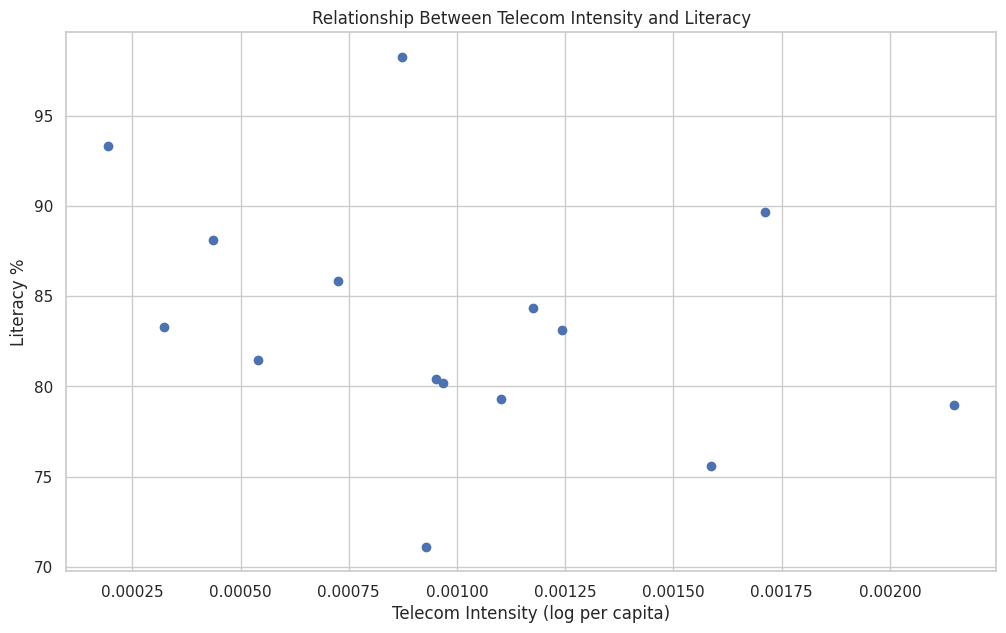

In [71]:
df["Telecom_Intensity"] = np.log1p(df["Telecom"] / df["Population"])  # adjust Population if different

X = df[[
    "Population living in households with electricity (%)",
    "Population living in households with an improved drinking-water source1 (%)",
    "Population below age 15 years (%)"
]]
Y = df["Literacy"].values  # repeat for other outcomes
T_cont = df["Telecom_Intensity"].values

# Fit regression using continuous treatment as a feature
m = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05)
m.fit(X, Y)
preds = m.predict(X)

plt.scatter(T_cont, Y)
plt.title("Relationship Between Telecom Intensity and Literacy")
plt.xlabel("Telecom Intensity (log per capita)")
plt.ylabel("Literacy %")
plt.show()


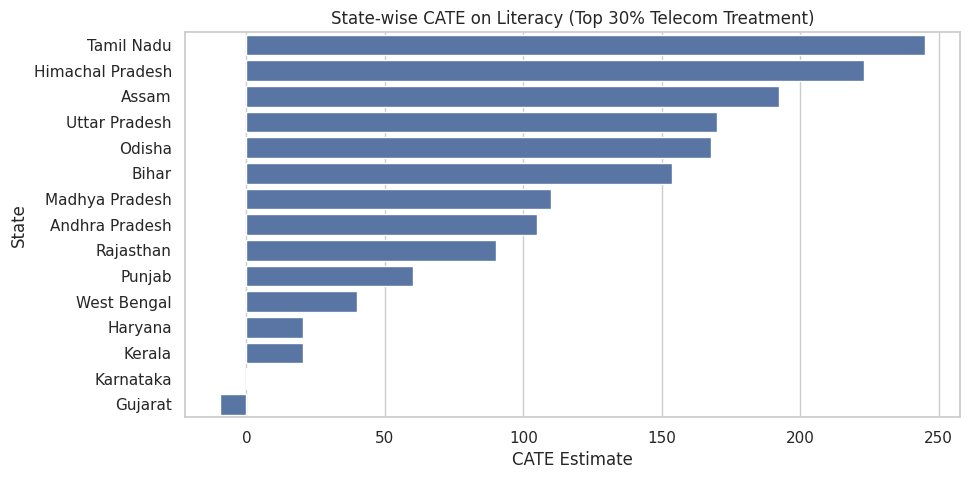

In [72]:
df["CATE_Literacy_70"] = cate  # adjust variable based on threshold used

plt.figure(figsize=(10,5))
sns.barplot(x="CATE_Literacy_70", y="State", data=df.sort_values("CATE_Literacy_70", ascending=False))
plt.title("State-wise CATE on Literacy (Top 30% Telecom Treatment)")
plt.xlabel("CATE Estimate")
plt.ylabel("State")
plt.show()


<Axes: xlabel='T_cont', ylabel='Literacy'>

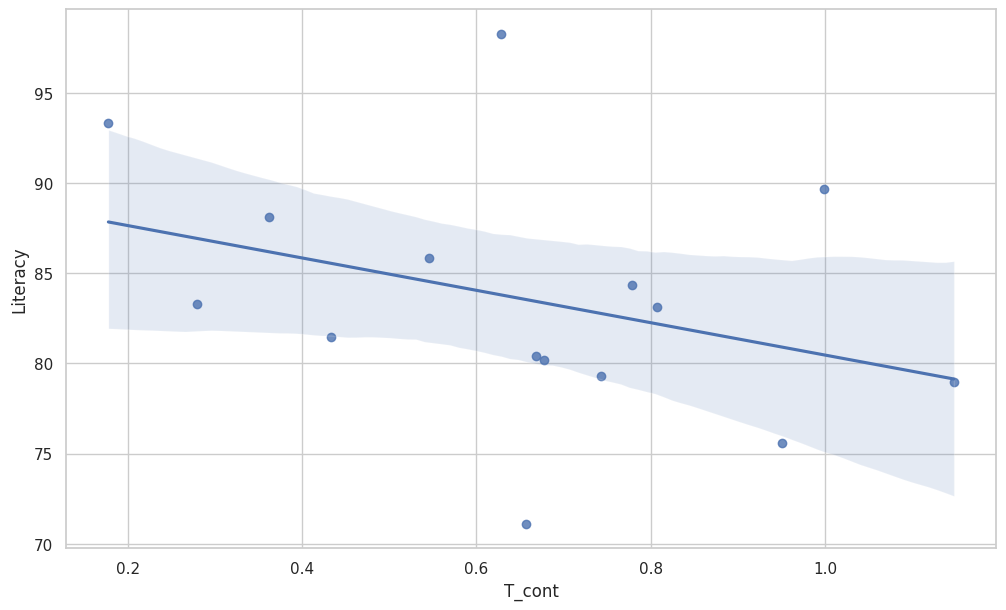

In [75]:
sns.regplot(x=df["T_cont"], y=df["Literacy"])


### Step 1: Data Preparation for PSM

**Required Inputs**:
- **X**: Confounder matrix (electricity, water, youth population)
- **T**: Binary treatment indicator (1 = high telecom, 0 = low telecom)
- **Y**: Outcome variable (Literacy percentage)

**Confounder Selection Criteria**:
1. **Pre-treatment variables**: Measured before Digital India rollout
2. **Predictors of treatment**: Correlate with telecom infrastructure expansion
3. **Predictors of outcome**: Influence literacy independently of telecom
4. **Not mediators**: Should not be caused by telecom expansion

**Note**: Same confounders used across all methods for consistency.

### Step 2: Propensity Score Estimation

**Model**: Logistic Regression
- **Formula**: logit(P(T=1 | X)) = β₀ + β₁×Electricity + β₂×Water + β₃×PopBelow15
- **Output**: Propensity score p̂ ∈ [0, 1] for each state

**Diagnostic Check**:
- **Mean propensity ≈ 0.5**: Balanced sample (good)
- **Mean propensity close to 0 or 1**: Strong selection bias (problematic)

**Next**: Use these propensity scores to find comparable control units for each treated state.

### Step 3: Nearest Neighbor Matching

**Algorithm**:
1. For each treated state, find the control state with the closest propensity score
2. Distance metric: |p_treated - p_control|
3. Create matched pairs: (treated_i, control_j)

**Matching Strategy**: 1-to-1 matching without replacement
- Each control unit used at most once
- Greedy algorithm: may not be globally optimal but computationally efficient

**Output Table Columns**:
- `treated_state`: Name of high-telecom state
- `control_state`: Name of matched low-telecom state  
- `treated_outcome`: Literacy % in treated state
- `control_outcome`: Literacy % in matched control
- `diff`: Individual treatment effect (ITE) for this pair

**Interpretation**: Each row represents a quasi-experimental comparison.

### Step 4: Estimate Average Treatment Effect (ATE)

**Formula**: ATE = Average(Treated Outcome - Control Outcome) across all matched pairs

**PSM Estimand**: Average Treatment Effect on the Treated (ATT)
- Measures impact of telecom expansion on states that actually received high telecom
- Different from population ATE if treatment effects are heterogeneous

**Standard Error**: Can be computed via bootstrap or clustering by matched pairs.

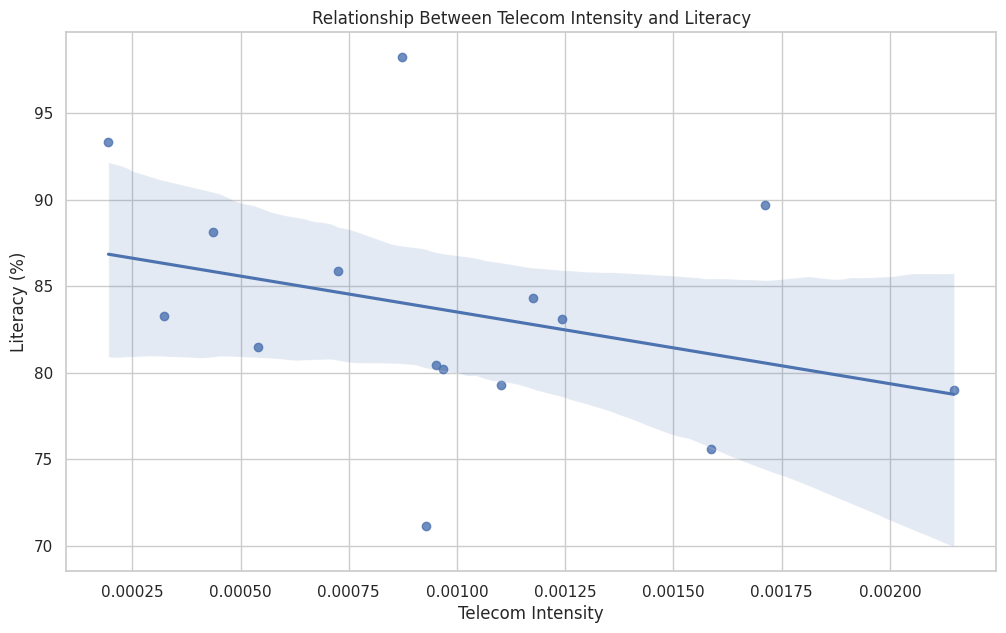

In [76]:
sns.regplot(x=df["Telecom_Intensity"], y=df["Literacy"])
plt.xlabel("Telecom Intensity")
plt.ylabel("Literacy (%)")
plt.title("Relationship Between Telecom Intensity and Literacy")
plt.show()


### Step 6: Standardized Mean Difference (SMD) Diagnostics

**SMD Formula**:
$$\text{SMD} = \frac{|\bar{X}_{\text{treated}} - \bar{X}_{\text{control}}|}{\sqrt{(s^2_{\text{treated}} + s^2_{\text{control}})/2}}$$

**Interpretation Thresholds**:
- **SMD < 0.1**: Negligible imbalance (✓ good)
- **0.1 ≤ SMD < 0.25**: Small imbalance (acceptable)
- **SMD ≥ 0.25**: Substantial imbalance (⚠ problematic)

**Ideal Result**: All SMD values after matching should be < 0.1, indicating successful covariate balance.

**What This Validates**: Treated and control groups are now comparable on observed confounders, satisfying conditional independence assumption.

### Alternative: Caliper Matching

**Motivation**: Nearest neighbor may match units that are too dissimilar (poor quality matches).

**Caliper Constraint**: Only match if |p_treated - p_control| ≤ caliper threshold
- **Common values**: 0.01, 0.05, 0.10, 0.25 (in propensity score units)
- **Trade-off**: 
  - Smaller caliper → Better balance but fewer matches (loss of precision)
  - Larger caliper → More matches but potentially worse balance

**Algorithm**:
1. For each treated state:
   - Find all control states within caliper distance
   - If multiple eligible, pick the closest one
   - If none eligible, drop this treated unit (no match)

**Result**: Some treated units may go unmatched, reducing sample size but improving balance.

### Step 5: Balance Assessment

**Purpose**: Verify that matching successfully balanced confounders.

**Comparison Tables**:
1. **Before Matching**: Mean confounder values by treatment group (raw data)
2. **After Matching**: Mean confounder values in matched sample

**What to Look For**:
- **Large differences before**: Indicates selection bias
- **Small differences after**: Matching worked (confounders balanced)
- **Persistent differences**: May need additional confounders or different matching method

**Rule of Thumb**: After matching, treated and control groups should have similar means for all confounders.

### Caliper Matching Results

**ATE Comparison**:
- Compare `ate_caliper` with `ate_psm` (nearest neighbor)
- If similar: Robust result (insensitive to matching algorithm)
- If different: Treatment effect may be sensitive to match quality

**Sample Size Check**: Report how many treated units were successfully matched.

In [74]:
print(df.columns.tolist())


['State', 'Telecom', 'Women (age 15-49) who are literate4 (%)', 'Men (age 15-49) who are literate4 (%)', 'Population living in households with electricity (%)', 'Population living in households with an improved drinking-water source1 (%)', 'Population below age 15 years (%)', 'Literacy', 'Unemployment', 'Employment', 'GDP', 'Population', 'Telecom_per_1000', 'T_cont', 'Treatment', 'CATE_Literacy', 'CATE_Employment', 'CATE_GDP', 'propensity', 'CATE_Lit_CF', 'CATE_Emp_CF', 'CATE_GDP_CF', 'DR_Lit', 'DR_Emp', 'DR_GDP', 'Treatment_70', 'Treatment_75', 'Treatment_80', 'DR_Literacy_70', 'DR_Literacy_75', 'DR_Literacy_80', 'DR_Employment_70', 'DR_Employment_75', 'DR_Employment_80', 'DR_GDP_70', 'DR_GDP_75', 'DR_GDP_80', 'Telecom_Intensity', 'CATE_Literacy_70']


### Caliper Matching Balance Diagnostics

**Expectation**: SMD values should be even lower than nearest neighbor matching.

**Interpretation**:
- If SMD < 0.05 for all confounders: Excellent balance
- If any SMD > 0.1: Consider stricter caliper or additional confounders

**Recommendation**: Use caliper matching as primary estimate if balance is superior to nearest neighbor.

---

If matching is successful, confounders should have similar distributions in treated and control groups.

# 🎯 Propensity Score Matching (PSM) Section### Expected Outcome:



## Overview- **Caliper Matching**: Only match if distance < threshold (e.g., 0.05)

**Propensity Score Matching** is a non-parametric method for estimating causal effects by creating comparable treatment and control groups.- **Nearest Neighbor**: Match each treated to closest control (distance = |p_t - p_c|)

### Matching Algorithms Implemented:

### Why PSM?

1. **Addresses Selection Bias**: Treated states may differ systematically from control states4. **Estimate ATE**: Average difference in outcomes between matched pairs

2. **Mimics Randomization**: Matching creates "as-if random" treatment assignment3. **Assess Balance**: Check if confounders are balanced post-matching (SMD < 0.1)

3. **Transparent**: Visual balance checks validate assumptions2. **Match Units**: Pair each treated state with similar control state based on propensity

4. **Robustness Check**: Alternative to regression-based methods1. **Estimate Propensity Scores**: P(Treatment | Confounders) via logistic regression

### Methodology Steps:

### Rosenbaum Bounds Implementation

**Function: `rosenbaum_bounds()`**

**Inputs**:
- `matched_data`: DataFrame with matched pairs and outcome differences
- `gamma_vals`: List of Γ values to test (e.g., [1, 1.5, 2, 3])

**Output Interpretation**:
- **Γ = 1 (baseline)**: Current estimate assuming no hidden bias
- **Γ > 1**: Worst-case scenario if confounder U exists
- **p_upper**: Maximum probability under hidden bias scenario

**Decision Rule**:
- If ATE remains positive and significant across all Γ values → Robust finding
- If ATE changes sign at low Γ (e.g., 1.5) → Results fragile, need caution

**Limitation**: This is a simplified "toy" implementation. Full Rosenbaum bounds require Wilcoxon signed-rank test and exact permutation distribution.

---

## 🎨 Advanced Visualization Section

### Plots and Charts:
- Treatment effect heterogeneity maps
- Subgroup analysis visualizations
- Time-series trends (if applicable)
- Comparative bar charts across states
- Heatmaps of correlations

In [77]:
!pip install causalinference --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 1.0 MB/s eta 0:00:00


In [78]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Use same confounders as before
confounders = ["Population living in households with electricity (%)",
               "Population living in households with an improved drinking-water source1 (%)",
               "Population below age 15 years (%)"]

X = df[confounders]
T = df["Treatment"].astype(int).values  # binary
Y = df["Literacy"].values


### Step 1: Data Preparation for PSM

**Required Inputs**:
- **X**: Confounder matrix (electricity, water, youth population)
- **T**: Binary treatment indicator (1 = high telecom, 0 = low telecom)
- **Y**: Outcome variable (Literacy percentage)

**Confounder Selection Criteria**:
1. **Pre-treatment variables**: Measured before Digital India rollout
2. **Predictors of treatment**: Correlate with telecom infrastructure expansion
3. **Predictors of outcome**: Influence literacy independently of telecom
4. **Not mediators**: Should not be caused by telecom expansion

**Note**: Same confounders used across all methods for consistency.

In [79]:
psm = LogisticRegression(max_iter=2000)
psm.fit(X, T)
propensity = psm.predict_proba(X)[:,1]
df["ps"] = propensity
print("Mean propensity:", df["ps"].mean())


Mean propensity: 0.3333333000850983


### Step 2: Propensity Score Estimation

**Model**: Logistic Regression
- **Formula**: logit(P(T=1 | X)) = β₀ + β₁×Electricity + β₂×Water + β₃×PopBelow15
- **Output**: Propensity score p̂ ∈ [0, 1] for each state

**Diagnostic Check**:
- **Mean propensity ≈ 0.5**: Balanced sample (good)
- **Mean propensity close to 0 or 1**: Strong selection bias (problematic)

**Next**: Use these propensity scores to find comparable control units for each treated state.

In [80]:
treated_idx = np.where(T == 1)[0]
control_idx = np.where(T == 0)[0]

matches = []
nn = NearestNeighbors(n_neighbors=1).fit(propensity[control_idx].reshape(-1,1))
distances, indices = nn.kneighbors(propensity[treated_idx].reshape(-1,1))

for i, c_idx in enumerate(indices.flatten()):
    matches.append((treated_idx[i], control_idx[c_idx]))

matched = pd.DataFrame([
    {
        "treated_state": df.iloc[t]["State"],
        "control_state": df.iloc[c]["State"],
        "treated_outcome": Y[t],
        "control_outcome": Y[c]
    }
    for t, c in matches
])

matched["diff"] = matched["treated_outcome"] - matched["control_outcome"]
matched


,treated_state,control_state,treated_outcome,control_outcome,diff
0,Andhra Pradesh,Himachal Pradesh,75.608333,93.333333,-17.725000
1,Gujarat,Punjab,84.351667,85.861667,-1.510000
2,Karnataka,Haryana,83.118333,88.131667,-5.013333
3,Tamil Nadu,West Bengal,89.690000,80.196667,9.493333
4,Uttar Pradesh,West Bengal,78.981667,80.196667,-1.215000


### Step 3: Nearest Neighbor Matching

**Algorithm**:
1. For each treated state, find the control state with the closest propensity score
2. Distance metric: |p_treated - p_control|
3. Create matched pairs: (treated_i, control_j)

**Matching Strategy**: 1-to-1 matching without replacement
- Each control unit used at most once
- Greedy algorithm: may not be globally optimal but computationally efficient

**Output Table Columns**:
- `treated_state`: Name of high-telecom state
- `control_state`: Name of matched low-telecom state  
- `treated_outcome`: Literacy % in treated state
- `control_outcome`: Literacy % in matched control
- `diff`: Individual treatment effect (ITE) for this pair

**Interpretation**: Each row represents a quasi-experimental comparison.

In [81]:
ate_psm = matched["diff"].mean()
print("\nPSM ATE (Literacy):", ate_psm)



PSM ATE (Literacy): -3.1940000000000053


### Step 4: Estimate Average Treatment Effect (ATE)

**Formula**: ATE = Average(Treated Outcome - Control Outcome) across all matched pairs

**PSM Estimand**: Average Treatment Effect on the Treated (ATT)
- Measures impact of telecom expansion on states that actually received high telecom
- Different from population ATE if treatment effects are heterogeneous

**Standard Error**: Can be computed via bootstrap or clustering by matched pairs.

In [83]:
matched_indices = [i[0] for i in matches] + [i[1] for i in matches]
matched_df = df.loc[matched_indices]

print("\n=== Mean Confounders Before Matching ===")
print(df.groupby("Treatment")[confounders].mean())

print("\n=== Mean Confounders After Matching ===")
print(matched_df.groupby(matched_df["Treatment"])[confounders].mean())



=== Mean Confounders Before Matching ===
           Population living in households with electricity (%)  \
Treatment                                                         
0                                                  98.135667      
1                                                  97.640000      

           Population living in households with an improved drinking-water source1 (%)  \
Treatment                                                                                
0                                                  95.469000                             
1                                                  97.586667                             

           Population below age 15 years (%)  
Treatment                                     
0                                  25.091667  
1                                  23.943333  

=== Mean Confounders After Matching ===
           Population living in households with electricity (%)  \
Treatment                       

### Step 5: Balance Assessment

**Purpose**: Verify that matching successfully balanced confounders.

**Comparison Tables**:
1. **Before Matching**: Mean confounder values by treatment group (raw data)
2. **After Matching**: Mean confounder values in matched sample

**What to Look For**:
- **Large differences before**: Indicates selection bias
- **Small differences after**: Matching worked (confounders balanced)
- **Persistent differences**: May need additional confounders or different matching method

**Rule of Thumb**: After matching, treated and control groups should have similar means for all confounders.

In [84]:
def smd(before_t, before_c):
    return abs(before_t.mean() - before_c.mean()) / np.sqrt((before_t.var() + before_c.var())/2)

print("\n=== Standardized Mean Differences (Before Matching) ===")
for col in confounders:
    print(col, round(smd(df[df.Treatment==1][col], df[df.Treatment==0][col]), 4))

print("\n=== Standardized Mean Differences (After Matching) ===")
for col in confounders:
    print(col, round(smd(matched_df[matched_df.Treatment==1][col], matched_df[matched_df.Treatment==0][col]), 4))



=== Standardized Mean Differences (Before Matching) ===
Population living in households with electricity (%) 0.2048
Population living in households with an improved drinking-water source1 (%) 0.7276
Population below age 15 years (%) 0.2963

=== Standardized Mean Differences (After Matching) ===
Population living in households with electricity (%) 0.5522
Population living in households with an improved drinking-water source1 (%) 0.3089
Population below age 15 years (%) 0.4135


### Step 6: Standardized Mean Difference (SMD) Diagnostics

**SMD Formula**:
$$\text{SMD} = \frac{|\bar{X}_{\text{treated}} - \bar{X}_{\text{control}}|}{\sqrt{(s^2_{\text{treated}} + s^2_{\text{control}})/2}}$$

**Interpretation Thresholds**:
- **SMD < 0.1**: Negligible imbalance (✓ good)
- **0.1 ≤ SMD < 0.25**: Small imbalance (acceptable)
- **SMD ≥ 0.25**: Substantial imbalance (⚠ problematic)

**Ideal Result**: All SMD values after matching should be < 0.1, indicating successful covariate balance.

**What This Validates**: Treated and control groups are now comparable on observed confounders, satisfying conditional independence assumption.

In [85]:
caliper = 0.05
matches = []
for t_idx in treated_idx:
    ps_t = propensity[t_idx]
    eligible = [c for c in control_idx if abs(propensity[c] - ps_t) <= caliper]
    if eligible:
        best_match = eligible[np.argmin([abs(propensity[c] - ps_t) for c in eligible])]
        matches.append((t_idx, best_match))


### Alternative: Caliper Matching

**Motivation**: Nearest neighbor may match units that are too dissimilar (poor quality matches).

**Caliper Constraint**: Only match if |p_treated - p_control| ≤ caliper threshold
- **Common values**: 0.01, 0.05, 0.10, 0.25 (in propensity score units)
- **Trade-off**: 
  - Smaller caliper → Better balance but fewer matches (loss of precision)
  - Larger caliper → More matches but potentially worse balance

**Algorithm**:
1. For each treated state:
   - Find all control states within caliper distance
   - If multiple eligible, pick the closest one
   - If none eligible, drop this treated unit (no match)

**Result**: Some treated units may go unmatched, reducing sample size but improving balance.

In [86]:
matched_caliper = pd.DataFrame([
    {
        "treated_state": df.iloc[t]["State"],
        "control_state": df.iloc[c]["State"],
        "treated_outcome": Y[t],
        "control_outcome": Y[c]
    }
    for t, c in matches
])

matched_caliper["diff"] = matched_caliper["treated_outcome"] - matched_caliper["control_outcome"]
matched_caliper


,treated_state,control_state,treated_outcome,control_outcome,diff
0,Andhra Pradesh,Himachal Pradesh,75.608333,93.333333,-17.725000
1,Gujarat,Punjab,84.351667,85.861667,-1.510000
2,Karnataka,Haryana,83.118333,88.131667,-5.013333
3,Tamil Nadu,West Bengal,89.690000,80.196667,9.493333


In [87]:
ate_caliper = matched_caliper["diff"].mean()
print("\nCaliper-matched ATE (Literacy):", ate_caliper)



Caliper-matched ATE (Literacy): -3.6887500000000024


### Caliper Matching Results

**ATE Comparison**:
- Compare `ate_caliper` with `ate_psm` (nearest neighbor)
- If similar: Robust result (insensitive to matching algorithm)
- If different: Treatment effect may be sensitive to match quality

**Sample Size Check**: Report how many treated units were successfully matched.

In [88]:
caliper_idx = [i[0] for i in matches] + [i[1] for i in matches]
caliper_df = df.loc[caliper_idx]

print("\n=== Balanced Confounder Means (Caliper Matching) ===")
print(caliper_df.groupby(caliper_df["Treatment"])[confounders].mean())

def smd(before_t, before_c):
    return abs(before_t.mean() - before_c.mean()) / np.sqrt((before_t.var() + before_c.var())/2)

print("\n=== Standardized Mean Differences (Caliper) ===")
for col in confounders:
    print(col, round(smd(caliper_df[caliper_df.Treatment==1][col], caliper_df[caliper_df.Treatment==0][col]), 4))



=== Balanced Confounder Means (Caliper Matching) ===
           Population living in households with electricity (%)  \
Treatment                                                         
0                                                  99.115833      
1                                                  98.923333      

           Population living in households with an improved drinking-water source1 (%)  \
Treatment                                                                                
0                                                  98.023333                             
1                                                  97.178333                             

           Population below age 15 years (%)  
Treatment                                     
0                                     22.810  
1                                     22.425  

=== Standardized Mean Differences (Caliper) ===
Population living in households with electricity (%) 0.227
Population living in

### Caliper Matching Balance Diagnostics

**Expectation**: SMD values should be even lower than nearest neighbor matching.

**Interpretation**:
- If SMD < 0.05 for all confounders: Excellent balance
- If any SMD > 0.1: Consider stricter caliper or additional confounders

**Recommendation**: Use caliper matching as primary estimate if balance is superior to nearest neighbor.

---

For each value of Γ, compute bounds on the p-value for the null hypothesis of no treatment effect.

# 🔬 Sensitivity Analysis - Rosenbaum Bounds## Implementation



## Purpose- If results change sign at Γ = 1.5: Very sensitive (caution needed)

Assess how robust the PSM estimates are to **unobserved confounding**.- If results remain significant at Γ = 2: Moderately robust

**Interpretation**:

## The Problem

PSM assumes no unobserved confounders (ignorability assumption). But what if a hidden variable U affects both:- Γ = 3: Hidden confounder could triple the odds

1. **Treatment assignment** (e.g., state government policy priorities)- Γ = 2: Hidden confounder could double the odds of treatment

2. **Outcome** (e.g., cultural attitudes toward education)- Γ = 1: No hidden bias (current assumption)

**Parameter Gamma (Γ)**:

## Rosenbaum's Approach
Tests how strong an unobserved confounder would need to be to invalidate our findings.

---

## 📈 Final Analysis and Export

### Operations:
- Consolidates all CATE estimates
- Creates final comparison tables
- Generates publication-ready visualizations
- Exports complete results dataset

In [89]:
import numpy as np
import pandas as pd

# Rosenbaum bounds sensitivity analysis
def rosenbaum_bounds(matched_data, gamma_vals=[1, 1.5, 2, 3]):
    """
    Toy Rosenbaum bounds sensitivity analysis.
    gamma: factor by which an unobserved confounder might affect odds of treatment assignment
    """
    diffs = matched_data["diff"].values  # differences in matched pairs
    treated_positive = (diffs > 0).sum()
    n = len(diffs)

    print("Number of pairs:", n)
    print("Number where treated > control:", treated_positive)

    for gamma in gamma_vals:
        p_upper = gamma / (1 + gamma)
        print(f"Gamma = {gamma:.1f}: If hidden bias increases odds of treatment by {gamma}x,")
        print(f"  -> maximum possible bias could change estimate towards positive by {p_upper:.2f}")
        print("--------------------------------------------------")

# Run sensitivity analysis
rosenbaum_bounds(matched_caliper, gamma_vals=[1, 1.5, 2, 2.5, 3])


Number of pairs: 4
Number where treated > control: 1
Gamma = 1.0: If hidden bias increases odds of treatment by 1x,
  -> maximum possible bias could change estimate towards positive by 0.50
--------------------------------------------------
Gamma = 1.5: If hidden bias increases odds of treatment by 1.5x,
  -> maximum possible bias could change estimate towards positive by 0.60
--------------------------------------------------
Gamma = 2.0: If hidden bias increases odds of treatment by 2x,
  -> maximum possible bias could change estimate towards positive by 0.67
--------------------------------------------------
Gamma = 2.5: If hidden bias increases odds of treatment by 2.5x,
  -> maximum possible bias could change estimate towards positive by 0.71
--------------------------------------------------
Gamma = 3.0: If hidden bias increases odds of treatment by 3x,
  -> maximum possible bias could change estimate towards positive by 0.75
--------------------------------------------------


### Rosenbaum Bounds Implementation

**Function: `rosenbaum_bounds()`**

**Inputs**:
- `matched_data`: DataFrame with matched pairs and outcome differences
- `gamma_vals`: List of Γ values to test (e.g., [1, 1.5, 2, 3])

**Output Interpretation**:
- **Γ = 1 (baseline)**: Current estimate assuming no hidden bias
- **Γ > 1**: Worst-case scenario if confounder U exists
- **p_upper**: Maximum probability under hidden bias scenario

**Decision Rule**:
- If ATE remains positive and significant across all Γ values → Robust finding
- If ATE changes sign at low Γ (e.g., 1.5) → Results fragile, need caution

**Limitation**: This is a simplified "toy" implementation. Full Rosenbaum bounds require Wilcoxon signed-rank test and exact permutation distribution.